In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.utils import resample

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

from scipy import stats
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from scipy.stats import f_oneway, chi2_contingency
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit

import matplotlib.patches as patches

In [93]:
df = pd.read_excel('covid_mental_health.xlsx')


columns_to_drop = [
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_others',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_others'
]
data1 = df.drop(columns=columns_to_drop)


columns_to_select = [
    'birth_year', 'country_ofResidence', 'Level_ofEducation', 'current_work_status',
    'do_youHave_medical_insurance', 'current_relationship_status', 'genderAt_birth',
    'pre_birth_year', 'pre_country_ofResidence', 'pre_Level_ofEducation', 'pre_current_work_status',
    'pre_do_youHave_medical_insurance', 'pre_current_relationship_status', 'pre_genderAt_birth',
    'having_difficulty_concentrating', 'feeling_irretablee_orHaving_angry_outburst',
    'trouble_falling_orStaying_asSleep', 'feeling_asIfYourFeature_willBer_cut_short',
    'feeling_emotional_numb_orBeeing_unble_toLoving_feeling_forThose_closeTo_you',
    'feeling_distant_from_other_people', 'loss_ofInterest_activity_that_you_enjoyed',
    'trouble_memembering_important_part_ofStressful_experience_from_past',
    'avoiding_activy_because_they_remind_you_stressful_experience_from_past',
    'avoiding_thinking_about_stressful_experience_from_past',
    'having_physical_reaction_when_somthing_remind_you_stressful_experience',
    'feeling_upset_when_something_remind_you_ofStressful_experience_fromPast',
    'suddenly_feel_asIf_aStressfull_experience_were_happening_again',
    'repeated_disturbing_dream_ofStressfull_experiencce_from_past',
    'repeated_disturbing_memory_though_image_ofStressfull_experiencce_from_past',
    'pre_having_difficulty_concentrating', 'pre_feeling_irretablee_orHaving_angry_outburst',
    'pre_trouble_falling_orStaying_asSleep', 'pre_feeling_asIfYourFeature_willBer_cut_short',
    'pre_feeling_emotional_numb_orBeeing_unble_toLoving_feeling_forThose_closeTo_you',
    'pre_feeling_distant_from_other_people', 'pre_trouble_memembering_important_part_ofStressful_experience_from_past',
    'pre_loss_ofInterest_activity_that_you_enjoyed',
    'pre_avoiding_activy_because_they_remind_you_stressful_experience_from_past',
    'pre_feeling_upset_when_something_remind_you_ofStressful_experience_fromPast',
    'pre_avoiding_thinking_about_stressful_experience_from_past',
    'pre_having_physical_reaction_when_somthing_remind_you_stressful_experience',
    'pre_suddenly_feel_asIf_aStressfull_experience_were_happening_again',
    'pre_repeated_disturbing_dream_ofStressfull_experiencce_from_past',
    'pre_repeated_disturbing_memory_though_image_ofStressfull_experiencce_from_past',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taked_toFNF_onPhone',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taked_toFNF_video_chat',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taked_toFNF_inPerson',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_spent_time_with_pet',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_meditation',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_exercise_inHome',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_exercise_outdoor',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_gardening',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_creative_activity',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_learn_new_skill',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taking_breaks_from_the_news',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_other',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taked_toFNF_onPhone',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taked_toFNF_video_chat',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taked_toFNF_inPerson',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_spent_time_with_pet',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_meditation',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_exercise_inHome',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_exercise_outdoor',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_gardening',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_creative_activity',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_learn_new_skill',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taking_breaks_from_the_news',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_other',
    'what_you_experiencing_during_covid_period_diagnosed_covid_positive',
    'what_you_experiencing_during_covid_period_fear_ofGetting_covid',
    'what_you_experiencing_during_covid_period_fear_ofGiving_covid',
    'what_you_experiencing_during_covid_period_worrying_about_people_otherThanMe',
    'what_you_experiencing_during_covid_period_stigma_from_other_people',
    'what_you_experiencing_during_covid_period_frustration',
    'what_you_experiencing_during_covid_period_anxiety',
    'what_you_experiencing_during_covid_period_depression',
    'what_you_experiencing_during_covid_period_loneliness',
    'what_you_experiencing_during_covid_period_anger',
    'what_you_experiencing_during_covid_period_grief_ofFeeling_ofLoss',
    'what_you_experiencing_during_covid_period_changing_sleep_patern',
    'what_you_experiencing_during_covid_period_notGetting_exercise',
    'what_you_experiencing_during_covid_period_notGetting_enough_emotionOrSocial_support',
    'what_you_experiencing_during_covid_period_notGetting_enough_financial_support',
    'what_you_experiencing_during_covid_period_confusion_about_covid',
    'what_you_experiencing_during_covid_period_confusion_about_where_toGet_info_about_covid',
    'what_you_experiencing_during_covid_period_difficulty_obtaining_mask',
    'what_you_experiencing_during_covid_period_difficulty_washing_hand',
    'what_you_experiencing_during_covid_period_none_ofThe_avobe',
    'pre_what_you_experiencing_during_covid_period_diagnosed_covid_positive',
    'pre_what_you_experiencing_during_covid_period_fear_ofGetting_covid',
    'pre_what_you_experiencing_during_covid_period_fear_ofGiving_covid',
    'pre_what_you_experiencing_during_covid_period_worrying_about_people_otherThanMe',
    'pre_what_you_experiencing_during_covid_period_stigma_from_other_people',
    'pre_what_you_experiencing_during_covid_period_frustration',
    'pre_what_you_experiencing_during_covid_period_anxiety',
    'pre_what_you_experiencing_during_covid_period_depression',
    'pre_what_you_experiencing_during_covid_period_loneliness',
    'pre_what_you_experiencing_during_covid_period_anger',
    'pre_what_you_experiencing_during_covid_period_grief_ofFeeling_ofLoss',
    'pre_what_you_experiencing_during_covid_period_changing_sleep_patern',
    'pre_what_you_experiencing_during_covid_period_notGetting_exercise',
    'pre_what_you_experiencing_during_covid_period_notGetting_enough_emotionOrSocial_support',
    'pre_what_you_experiencing_during_covid_period_notGetting_enough_financial_support',
    'pre_what_you_experiencing_during_covid_period_confusion_about_covid',
    'pre_what_you_experiencing_during_covid_period_confusion_about_where_toGet_info_about_covid',
    'pre_what_you_experiencing_during_covid_period_difficulty_obtaining_mask',
    'pre_what_you_experiencing_during_covid_period_difficulty_washing_hand',
    'pre_what_you_experiencing_during_covid_period_none_ofThe_avobe',
    'what_you_experiencing_during_covid_period_anxiety',
    'what_you_experiencing_during_covid_period_depression',
    'what_you_experiencing_during_covid_period_loneliness',
    'what_you_experiencing_during_covid_period_anger',
    'what_you_experiencing_during_covid_period_frustration',
    'what_you_experiencing_during_covid_period_grief_ofFeeling_ofLoss',
    'what_you_experiencing_during_covid_period_changing_sleep_patern',
    'what_you_experiencing_during_covid_period_notGetting_exercise',
    'what_you_experiencing_during_covid_period_fear_ofGetting_covid',
    'what_you_experiencing_during_covid_period_fear_ofGiving_covid',
    'what_you_experiencing_during_covid_period_worrying_about_people_otherThanMe',
    'what_you_experiencing_during_covid_period_stigma_from_other_people',
    'what_you_experiencing_during_covid_period_notGetting_enough_emotionOrSocial_support'
]

data = data1[columns_to_select]


pre_columns = [col for col in columns_to_select if col.startswith('pre_')]
post_columns = [col for col in columns_to_select if not col.startswith('pre_')]

data_pre = data[pre_columns]
data_post = data[post_columns].loc[:, ~data[post_columns].columns.duplicated()]

In [94]:
data_pre['pre_current_work_status'] = np.where(data_pre['pre_current_work_status'].isin([1,2,3]), 1, 2)


print(data_pre['pre_current_work_status'].value_counts())

pre_current_work_status
1    216
2    122
Name: count, dtype: int64


In [95]:
data_post['current_work_status'] = np.where(data_post['current_work_status'].isin([1,2,3]), 1, 2)

In [96]:
data_post['current_work_status'].value_counts()

current_work_status
1    227
2    111
Name: count, dtype: int64

In [97]:
data_pre['pre_genderAt_birth'] = data_pre['pre_genderAt_birth'].replace({3: 2})

In [98]:
data_pre['pre_genderAt_birth'].value_counts()

pre_genderAt_birth
2    186
1    152
Name: count, dtype: int64

In [99]:
data_post['genderAt_birth'] = data_post['genderAt_birth'].replace({3: 2})

In [100]:
data_post['genderAt_birth'].value_counts()

genderAt_birth
2    176
1    162
Name: count, dtype: int64

In [101]:
data_pre['pre_country_ofResidence'].value_counts()

pre_country_ofResidence
127.0    149
66.0      18
77.0      16
132.0     16
162.0     15
188.0     10
187.0      8
184.0      7
197.0      6
152.0      6
52.0       6
32.0       5
35.0       5
86.0       5
111.0      5
7.0        4
97.0       3
22.0       3
60.0       3
124.0      3
138.0      3
181.0      2
167.0      2
24.0       2
88.0       2
193.0      2
120.0      2
195.0      2
75.0       2
123.0      1
9.0        1
154.0      1
103.0      1
98.0       1
80.0       1
142.0      1
186.0      1
79.0       1
67.0       1
139.0      1
85.0       1
61.0       1
156.0      1
83.0       1
172.0      1
90.0       1
141.0      1
174.0      1
37.0       1
91.0       1
78.0       1
175.0      1
165.0      1
145.0      1
104.0      1
Name: count, dtype: int64

In [102]:
country_mapping = {
    127: 'nigeria',
    66: 'srilanka',
    77: 'togo',
    132: 'pakistan',
    162: 'south africa',
    188: 'USA',
    187: 'UK',
    184: 'uganda',
    152: 'saudi arabia',
    52: 'egypt',
    197: 'zimbabwe',
    111: 'mexico',
    32: 'canada',
    35: 'chile',
    86: 'jordan',
    7: 'argentina',
    124: 'new zealand',
    60: 'finland',
    22: 'bosnia herzegovina',
    138: 'peru',
    97: 'liberia',
    167: 'sudan',
    24: 'brazil',
    120: 'namibia',
    195: 'yemen',
    181: 'turkey',
    75: 'hungary',
    88: 'kenya',
    193: 'venezuela',
    156: 'sierra leone',
    90: 'kosovo',
    78: 'indonesia',
    175: 'thailand',
    165: 'spain',
    145: 'rwanda',
    141: 'portugal',
    172: 'taiwan',
    37: 'colombia',
    91: 'kuwait',
    85: 'japan',
    61: 'france',
    83: 'italy',
    139: 'philippines',
    174: 'tanzania',
    142: 'qatar',
    79: 'iran',
    123: 'netherlands',
    67: 'greece',
    9: 'australia',
    80: 'iraq',
    154: 'serbia',
    98: 'libya',
    103: 'malawi',
    186: 'UAE',
    104: 'malaysia',
}


data_pre['pre_country_ofResidence'] = data_pre['pre_country_ofResidence'].map(country_mapping)
print(data_pre['pre_country_ofResidence'].value_counts())

pre_country_ofResidence
nigeria               149
srilanka               18
togo                   16
pakistan               16
south africa           15
USA                    10
UK                      8
uganda                  7
zimbabwe                6
saudi arabia            6
egypt                   6
canada                  5
chile                   5
jordan                  5
mexico                  5
argentina               4
liberia                 3
bosnia herzegovina      3
finland                 3
new zealand             3
peru                    3
turkey                  2
sudan                   2
brazil                  2
kenya                   2
venezuela               2
namibia                 2
yemen                   2
hungary                 2
netherlands             1
australia               1
serbia                  1
malawi                  1
libya                   1
iraq                    1
qatar                   1
UAE                     1
iran          

In [103]:
country_to_income = {
    # High income (4)
    'usa': 4,
    'uk': 4,
    'canada': 4,
    'finland': 4,
    'new zealand': 4,
    'japan': 4,
    'france': 4,
    'italy': 4,
    'spain': 4,
    'portugal': 4,
    'netherlands': 4,
    'australia': 4,
    'qatar': 4,
    'kuwait': 4,
    'saudi arabia': 4,
    'uae': 4,
    'taiwan': 4,
    'ireland': 4,
    'greece': 4,
    'hungary': 4,
    
    # Upper-middle income (3)
    'south africa': 3,
    'mexico': 3,
    'chile': 3,
    'argentina': 3,
    'brazil': 3,
    'peru': 3,
    'colombia': 3,
    'turkey': 3,
    'venezuela': 3,
    'iran': 3,
    'malaysia': 3,
    'bosnia herzegovina': 3,
    'serbia': 3,
    'libya': 3,
    'kosovo': 3,
    
    # Lower-middle income (2)
    'pakistan': 2,
    'srilanka': 2,
    'egypt': 2,
    'jordan': 2,
    'indonesia': 2,
    'philippines': 2,
    'thailand': 2,
    'yemen': 2,
    'iraq': 2,
    'namibia': 2,
    'bangladesh': 2,
    'botswana': 2,
    'ethiopia': 2,
    'mali': 2,
    
    # Low income (1)
    'nigeria': 1,
    'uganda': 1,
    'zimbabwe': 1,
    'liberia': 1,
    'sudan': 1,
    'kenya': 1,
    'rwanda': 1,
    'tanzania': 1,
    'sierra leone': 1,
    'malawi': 1,
    'togo': 1,
}


def map_income(country):
    if pd.isna(country):
        return 1
    return country_to_income.get(str(country).strip().lower(), 0)


data_pre['Country Income Profile'] = data_pre['pre_country_ofResidence'].apply(map_income)

print("\nIncome profile counts:")
print(data_pre['Country Income Profile'].value_counts().sort_index())


Income profile counts:
Country Income Profile
1    189
2     53
3     47
4     49
Name: count, dtype: int64


In [104]:
data_post['country_ofResidence'].value_counts()

country_ofResidence
127.0    154
66.0      22
77.0      15
132.0     14
162.0     13
188.0      9
197.0      7
187.0      7
184.0      6
52.0       6
86.0       6
32.0       5
111.0      4
152.0      4
7.0        4
124.0      4
193.0      3
88.0       3
35.0       3
22.0       3
138.0      3
97.0       3
9.0        3
181.0      2
141.0      2
167.0      2
120.0      2
60.0       2
139.0      2
195.0      2
58.0       1
23.0       1
81.0       1
103.0      1
154.0      1
75.0       1
67.0       1
104.0      1
80.0       1
174.0      1
142.0      1
37.0       1
79.0       1
85.0       1
61.0       1
14.0       1
83.0       1
24.0       1
145.0      1
165.0      1
175.0      1
78.0       1
106.0      1
Name: count, dtype: int64

In [105]:
country_mapping_post = {
    127: 'nigeria',
    66: 'srilanka',
    77: 'togo',
    132: 'pakistan',
    162: 'south africa',
    188: 'USA',
    197: 'zimbabwe',
    187: 'UK',
    52: 'egypt',
    184: 'uganda',
    86: 'jordan',
    32: 'canada',
    111: 'mexico',
    152: 'saudi arabia',
    124: 'new zealand',
    7: 'argentina',
    9: 'australia',
    35: 'chile',
    97: 'liberia',
    88: 'kenya',
    138: 'peru',
    193: 'venezuela',
    22: 'bosnia herzegovina',
    139: 'philippines',
    60: 'finland',
    120: 'namibia',
    141: 'portugal',
    181: 'turkey',
    195: 'yemen',
    167: 'sudan',
    37: 'colombia',
    175: 'thailand',
    165: 'spain',
    145: 'rwanda',
    78: 'indonesia',
    174: 'tanzania',
    83: 'italy',
    79: 'iran',
    85: 'japan',
    61: 'france',
    14: 'bangladesh',
    24: 'brazil',
    67: 'greece',
    80: 'iraq',
    142: 'qatar',
    103: 'malawi',
    154: 'serbia',
    58: 'ethiopia',
    23: 'botswana',
    81: 'ireland',
    75: 'hungary',
    104: 'malaysia',
    106: 'mali',
}


data_post['country_ofResidence'] = data_post['country_ofResidence'].map(country_mapping_post)

print("Country distribution after mapping:")
print(data_post['country_ofResidence'].value_counts())

Country distribution after mapping:
country_ofResidence
nigeria               154
srilanka               22
togo                   15
pakistan               14
south africa           13
USA                     9
zimbabwe                7
UK                      7
uganda                  6
egypt                   6
jordan                  6
canada                  5
mexico                  4
saudi arabia            4
argentina               4
new zealand             4
venezuela               3
kenya                   3
chile                   3
bosnia herzegovina      3
peru                    3
liberia                 3
australia               3
turkey                  2
portugal                2
sudan                   2
namibia                 2
finland                 2
philippines             2
yemen                   2
ethiopia                1
botswana                1
ireland                 1
malawi                  1
serbia                  1
hungary                 1
greece  

In [106]:
country_to_income_post = {
    # High income (4)
    'usa': 4,
    'uk': 4,
    'canada': 4,
    'finland': 4,
    'new zealand': 4,
    'australia': 4,
    'japan': 4,
    'france': 4,
    'italy': 4,
    'spain': 4,
    'portugal': 4,
    'netherlands': 4,
    'ireland': 4,
    'qatar': 4,
    'kuwait': 4,
    'saudi arabia': 4,
    'uae': 4,
    'hungary': 4,
    'greece': 4,
    
    # Upper-middle income (3)
    'south africa': 3,
    'mexico': 3,
    'chile': 3,
    'argentina': 3,
    'brazil': 3,
    'peru': 3,
    'colombia': 3,
    'turkey': 3,
    'venezuela': 3,
    'iran': 3,
    'malaysia': 3,
    'bosnia herzegovina': 3,
    'serbia': 3,
    'libya': 3,
    'botswana': 3,
    
    # Lower-middle income (2)
    'pakistan': 2,
    'srilanka': 2,
    'egypt': 2,
    'jordan': 2,
    'indonesia': 2,
    'philippines': 2,
    'thailand': 2,
    'yemen': 2,
    'iraq': 2,
    'namibia': 2,
    'bangladesh': 2,
    
    # Low income (1)
    'nigeria': 1,
    'uganda': 1,
    'zimbabwe': 1,
    'liberia': 1,
    'sudan': 1,
    'kenya': 1,
    'rwanda': 1,
    'tanzania': 1,
    'sierra leone': 1,
    'malawi': 1,
    'togo': 1,
    'ethiopia': 1,
    'mali': 1,
}

def map_income_post(country):
    if pd.isna(country):
        return 1
    return country_to_income_post.get(str(country).strip().lower(), 0)

data_post['Country Income Profile'] = data_post['country_ofResidence'].apply(map_income_post)

print("\nIncome profile counts (Post-Pandemic):")
print(data_post['Country Income Profile'].value_counts().sort_index())


Income profile counts (Post-Pandemic):
Country Income Profile
1    195
2     58
3     41
4     44
Name: count, dtype: int64


In [107]:
ptss_categories_pre = [
    'pre_repeated_disturbing_dream_ofStressfull_experiencce_from_past',
    'pre_repeated_disturbing_memory_though_image_ofStressfull_experiencce_from_past',
    'pre_suddenly_feel_asIf_aStressfull_experience_were_happening_again',
    'pre_feeling_upset_when_something_remind_you_ofStressful_experience_fromPast',
    'pre_avoiding_activy_because_they_remind_you_stressful_experience_from_past',
    'pre_having_physical_reaction_when_somthing_remind_you_stressful_experience',
    'pre_avoiding_thinking_about_stressful_experience_from_past',
    'pre_loss_ofInterest_activity_that_you_enjoyed',
    'pre_feeling_emotional_numb_orBeeing_unble_toLoving_feeling_forThose_closeTo_you',
    'pre_feeling_asIfYourFeature_willBer_cut_short',
    'pre_having_difficulty_concentrating',
    'pre_feeling_irretablee_orHaving_angry_outburst',
    'pre_trouble_falling_orStaying_asSleep',
    'pre_trouble_memembering_important_part_ofStressful_experience_from_past',
    'pre_feeling_distant_from_other_people'
]

coping_categories_pre = [
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taked_toFNF_onPhone',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taked_toFNF_video_chat',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taked_toFNF_inPerson',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_exercise_inHome',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_exercise_outdoor',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_gardening',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_meditation',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_creative_activity',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_learn_new_skill',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taking_breaks_from_the_news',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_spent_time_with_pet'
]

mh_categories_pre = [
    'pre_what_you_experiencing_during_covid_period_anxiety',
    'pre_what_you_experiencing_during_covid_period_depression',
    'pre_what_you_experiencing_during_covid_period_loneliness',
    'pre_what_you_experiencing_during_covid_period_anger',
    'pre_what_you_experiencing_during_covid_period_frustration',
    'pre_what_you_experiencing_during_covid_period_grief_ofFeeling_ofLoss',
    'pre_what_you_experiencing_during_covid_period_changing_sleep_patern',
    'pre_what_you_experiencing_during_covid_period_notGetting_exercise',
    'pre_what_you_experiencing_during_covid_period_fear_ofGetting_covid',
    'pre_what_you_experiencing_during_covid_period_fear_ofGiving_covid',
    'pre_what_you_experiencing_during_covid_period_worrying_about_people_otherThanMe',
    'pre_what_you_experiencing_during_covid_period_stigma_from_other_people',
    'pre_what_you_experiencing_during_covid_period_notGetting_enough_emotionOrSocial_support',
    'pre_what_you_experiencing_during_covid_period_confusion_about_covid',
    'pre_what_you_experiencing_during_covid_period_confusion_about_where_toGet_info_about_covid'
]

data_pre.loc[:, 'ptss_score'] = data_pre.loc[:, ptss_categories_pre].sum(axis=1)
data_pre.loc[:, 'coping_categories_score'] = data_pre.loc[:, coping_categories_pre].sum(axis=1)
data_pre.loc[:, 'mental_health_score'] = data_pre.loc[:, mh_categories_pre].sum(axis=1)

all_vars_to_drop_pre = ptss_categories_pre + coping_categories_pre + mh_categories_pre
data_pre = data_pre.drop(columns=all_vars_to_drop_pre)

In [108]:
data_pre['pre_birth_year'] = data_pre['pre_birth_year'].astype(int)
reference_year_pre = 2022
data_pre['current_age_pre'] = reference_year_pre - data_pre['pre_birth_year']

In [109]:
data_pre = data_pre.drop(columns=[
    'pre_birth_year', 'pre_do_youHave_medical_insurance',
    'pre_current_relationship_status',
    'pre_what_things_you_done_toTakeCare_ofMentalHealth_during_covid_other',
    'pre_what_you_experiencing_during_covid_period_diagnosed_covid_positive',
    'pre_what_you_experiencing_during_covid_period_none_ofThe_avobe'
])


rename_dict_pre = {
    'pre_Level_ofEducation': 'Level of Education',
    'pre_current_work_status': 'Work Status',
    'pre_genderAt_birth': 'Gender',
    'current_age_pre': 'Age',
    'ptss_score': 'PTSS Symptoms',
    'coping_categories_score': 'Coping Strategy',
    'mental_health_score': 'Pandemic Stress'
}
data_pre = data_pre.rename(columns=rename_dict_pre)

data_pre = data_pre[['Country Income Profile', 'Level of Education', 'Work Status',
                     'Gender', 'PTSS Symptoms', 'Coping Strategy', 'Pandemic Stress', 'Age']]

In [110]:
ptss_categories_post = [
    'repeated_disturbing_dream_ofStressfull_experiencce_from_past',
    'repeated_disturbing_memory_though_image_ofStressfull_experiencce_from_past',
    'suddenly_feel_asIf_aStressfull_experience_were_happening_again',
    'feeling_upset_when_something_remind_you_ofStressful_experience_fromPast',
    'having_physical_reaction_when_somthing_remind_you_stressful_experience',
    'avoiding_activy_because_they_remind_you_stressful_experience_from_past',
    'avoiding_thinking_about_stressful_experience_from_past',
    'trouble_memembering_important_part_ofStressful_experience_from_past',
    'loss_ofInterest_activity_that_you_enjoyed',
    'feeling_distant_from_other_people',
    'feeling_emotional_numb_orBeeing_unble_toLoving_feeling_forThose_closeTo_you',
    'feeling_asIfYourFeature_willBer_cut_short',
    'having_difficulty_concentrating',
    'feeling_irretablee_orHaving_angry_outburst',
    'trouble_falling_orStaying_asSleep'
]

coping_categories_post = [
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taked_toFNF_onPhone',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taked_toFNF_video_chat',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taked_toFNF_inPerson',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_exercise_inHome',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_exercise_outdoor',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_gardening',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_meditation',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_creative_activity',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_learn_new_skill',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_taking_breaks_from_the_news',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_spent_time_with_pet'
]

mh_categories_post = [
    'what_you_experiencing_during_covid_period_anxiety',
    'what_you_experiencing_during_covid_period_depression',
    'what_you_experiencing_during_covid_period_loneliness',
    'what_you_experiencing_during_covid_period_anger',
    'what_you_experiencing_during_covid_period_frustration',
    'what_you_experiencing_during_covid_period_grief_ofFeeling_ofLoss',
    'what_you_experiencing_during_covid_period_changing_sleep_patern',
    'what_you_experiencing_during_covid_period_notGetting_exercise',
    'what_you_experiencing_during_covid_period_fear_ofGetting_covid',
    'what_you_experiencing_during_covid_period_fear_ofGiving_covid',
    'what_you_experiencing_during_covid_period_worrying_about_people_otherThanMe',
    'what_you_experiencing_during_covid_period_stigma_from_other_people',
    'what_you_experiencing_during_covid_period_notGetting_enough_emotionOrSocial_support',
    'what_you_experiencing_during_covid_period_confusion_about_covid',
    'what_you_experiencing_during_covid_period_confusion_about_where_toGet_info_about_covid'
]

data_post.loc[:, 'ptss_score'] = data_post.loc[:, ptss_categories_post].sum(axis=1)
data_post.loc[:, 'coping_strategy_score'] = data_post.loc[:, coping_categories_post].sum(axis=1)
data_post.loc[:, 'mental_health_score'] = data_post.loc[:, mh_categories_post].sum(axis=1)

all_vars_to_drop_post = ptss_categories_post + coping_categories_post + mh_categories_post
data_post = data_post.drop(columns=all_vars_to_drop_post)

In [111]:
data_post['birth_year'] = data_post['birth_year'].astype(int)
reference_year_post = 2021
data_post['current_age_post'] = reference_year_post - data_post['birth_year']

In [112]:
data_post = data_post.drop(columns=[
    'birth_year', 'do_youHave_medical_insurance',
    'what_you_experiencing_during_covid_period_none_ofThe_avobe',
    'current_relationship_status',
    'what_things_you_done_toTakeCare_ofMentalHealth_during_covid_other',
    'what_you_experiencing_during_covid_period_diagnosed_covid_positive'
])


rename_dict_post = {
    'Level_ofEducation': 'Level of Education',
    'current_work_status': 'Work Status',
    'genderAt_birth': 'Gender',
    'current_age_post': 'Age',
    'ptss_score': 'PTSS Symptoms',
    'coping_strategy_score': 'Coping Strategy',
    'mental_health_score': 'Pandemic Stress'
}
data_post = data_post.rename(columns=rename_dict_post)

data_post = data_post[['Country Income Profile', 'Level of Education', 'Work Status',
                       'Gender', 'PTSS Symptoms', 'Coping Strategy', 'Pandemic Stress', 'Age']]

In [113]:
# Run this in a single cell to see the range of 'Pandemic Stress' in both waves
print("Pre (Wave 1):")
print(f"  Min    = {data_pre['Pandemic Stress'].min():.3f}")
print(f"  Max    = {data_pre['Pandemic Stress'].max():.3f}")
print(f"  Range  = {data_pre['Pandemic Stress'].max() - data_pre['Pandemic Stress'].min():.2f}")

print("Post (Wave 2):")
print(f"  Min    = {data_post['Pandemic Stress'].min():.3f}")
print(f"  Max    = {data_post['Pandemic Stress'].max():.3f}")
print(f"  Range  = {data_post['Pandemic Stress'].max() - data_post['Pandemic Stress'].min():.3f}")

Pre (Wave 1):
  Min    = 0.000
  Max    = 14.000
  Range  = 14.00
Post (Wave 2):
  Min    = 0.000
  Max    = 15.000
  Range  = 15.000


In [114]:
features = ['PTSS Symptoms', 'Coping Strategy', 'Pandemic Stress']

scaler_pre = StandardScaler()
scaler_post = StandardScaler()

data_pre_scaled = scaler_pre.fit_transform(data_pre[features])
data_post_scaled = scaler_post.fit_transform(data_post[features])

k_values = range(2, 7)
results_pre = []
results_post = []

print("=" * 80)
print("CLUSTERING METRICS ACROSS k = 2 TO 6")
print("=" * 80)

for k in k_values:
    kmeans_pre = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_post = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels_pre_kmeans = kmeans_pre.fit_predict(data_pre_scaled)
    labels_post_kmeans = kmeans_post.fit_predict(data_post_scaled)
    
    gmm_pre = GaussianMixture(n_components=k, random_state=42)
    gmm_post = GaussianMixture(n_components=k, random_state=42)
    
    labels_pre_gmm = gmm_pre.fit_predict(data_pre_scaled)
    labels_post_gmm = gmm_post.fit_predict(data_post_scaled)
    
    results_pre.append({
        'k': k,
        'Method': 'K-Means',
        'Silhouette': silhouette_score(data_pre_scaled, labels_pre_kmeans),
        'Davies-Bouldin': davies_bouldin_score(data_pre_scaled, labels_pre_kmeans),
        'Calinski-Harabasz': calinski_harabasz_score(data_pre_scaled, labels_pre_kmeans),
        'BIC': None,
        'AIC': None
    })
    
    results_pre.append({
        'k': k,
        'Method': 'GMM',
        'Silhouette': silhouette_score(data_pre_scaled, labels_pre_gmm),
        'Davies-Bouldin': davies_bouldin_score(data_pre_scaled, labels_pre_gmm),
        'Calinski-Harabasz': calinski_harabasz_score(data_pre_scaled, labels_pre_gmm),
        'BIC': gmm_pre.bic(data_pre_scaled),
        'AIC': gmm_pre.aic(data_pre_scaled)
    })
    

    results_post.append({
        'k': k,
        'Method': 'K-Means',
        'Silhouette': silhouette_score(data_post_scaled, labels_post_kmeans),
        'Davies-Bouldin': davies_bouldin_score(data_post_scaled, labels_post_kmeans),
        'Calinski-Harabasz': calinski_harabasz_score(data_post_scaled, labels_post_kmeans),
        'BIC': None,
        'AIC': None
    })
    
    results_post.append({
        'k': k,
        'Method': 'GMM',
        'Silhouette': silhouette_score(data_post_scaled, labels_post_gmm),
        'Davies-Bouldin': davies_bouldin_score(data_post_scaled, labels_post_gmm),
        'Calinski-Harabasz': calinski_harabasz_score(data_post_scaled, labels_post_gmm),
        'BIC': gmm_post.bic(data_post_scaled),
        'AIC': gmm_post.aic(data_post_scaled)
    })


df_pre = pd.DataFrame(results_pre)
df_post = pd.DataFrame(results_post)

print("\n--- FIRST WAVE (Pre-Pandemic) ---")
print(df_pre.to_string(index=False))
print("\n--- SECOND WAVE (Post-Pandemic) ---")
print(df_post.to_string(index=False))


CLUSTERING METRICS ACROSS k = 2 TO 6

--- FIRST WAVE (Pre-Pandemic) ---
 k  Method  Silhouette  Davies-Bouldin  Calinski-Harabasz         BIC         AIC
 2 K-Means    0.355226        1.218684         173.966260         NaN         NaN
 2     GMM    0.302767        1.366091         153.006448 2714.768142 2642.130270
 3 K-Means    0.313539        1.065124         187.513581         NaN         NaN
 3     GMM    0.187216        1.276454          96.213183 2685.221020 2574.352689
 4 K-Means    0.299907        1.130458         168.103200         NaN         NaN
 4     GMM    0.183910        1.465753          95.152654 2715.177960 2566.079170
 5 K-Means    0.295691        1.106190         159.458416         NaN         NaN
 5     GMM    0.241089        1.235926         124.228854 2795.949813 2608.620564
 6 K-Means    0.297064        1.045368         159.886381         NaN         NaN
 6     GMM    0.142192        1.377926          93.877728 2746.239438 2520.679730

--- SECOND WAVE (Post-Pan

In [115]:
def gap_statistic(data, max_k=6, n_refs=10):
    """Compute Gap statistic for K-Means clustering."""
    from sklearn.metrics import pairwise_distances
    
    gaps = []
    standard_errors = []
    K_range = range(1, max_k + 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        centers = kmeans.cluster_centers_
        
       
        Wk = 0
        for i in range(k):
            cluster_points = data[labels == i]
            if len(cluster_points) > 1:
                distances = pairwise_distances(cluster_points, [centers[i]])
                Wk += np.sum(distances ** 2) / (2 * len(cluster_points))
        
        
        ref_Wks = []
        for _ in range(n_refs):
            ref_data = np.random.uniform(
                low=data.min(axis=0),
                high=data.max(axis=0),
                size=data.shape
            )
            ref_kmeans = KMeans(n_clusters=k, random_state=None, n_init=10)
            ref_labels = ref_kmeans.fit_predict(ref_data)
            ref_centers = ref_kmeans.cluster_centers_
            
            ref_Wk = 0
            for j in range(k):
                ref_cluster_points = ref_data[ref_labels == j]
                if len(ref_cluster_points) > 1:
                    ref_distances = pairwise_distances(ref_cluster_points, [ref_centers[j]])
                    ref_Wk += np.sum(ref_distances ** 2) / (2 * len(ref_cluster_points))
            ref_Wks.append(np.log(ref_Wk))
        
        
        gaps.append(np.mean(ref_Wks) - np.log(Wk))
        standard_errors.append(np.std(ref_Wks) * np.sqrt(1 + 1/n_refs))
    
    return K_range, gaps, standard_errors


K_range_pre, gaps_pre, se_pre = gap_statistic(data_pre_scaled, max_k=6)
K_range_post, gaps_post, se_post = gap_statistic(data_post_scaled, max_k=6)


print("GAP STATISTIC RESULTS")
print("-" * 80)
print("\n--- First Wave ---")
for k, gap, se in zip(K_range_pre, gaps_pre, se_pre):
    print(f"k={k}: Gap = {gap:.4f} ± {se:.4f}")

print("\n--- Second Wave ---")
for k, gap, se in zip(K_range_post, gaps_post, se_post):
    print(f"k={k}: Gap = {gap:.4f} ± {se:.4f}")


GAP STATISTIC RESULTS
--------------------------------------------------------------------------------

--- First Wave ---
k=1: Gap = 0.4792 ± 0.0331
k=2: Gap = 0.4902 ± 0.0206
k=3: Gap = 0.5759 ± 0.0336
k=4: Gap = 0.4790 ± 0.0261
k=5: Gap = 0.4077 ± 0.0422
k=6: Gap = 0.4339 ± 0.0219

--- Second Wave ---
k=1: Gap = 0.5021 ± 0.0266
k=2: Gap = 0.5271 ± 0.0319
k=3: Gap = 0.5646 ± 0.0143
k=4: Gap = 0.5428 ± 0.0214
k=5: Gap = 0.5000 ± 0.0346
k=6: Gap = 0.4290 ± 0.0412


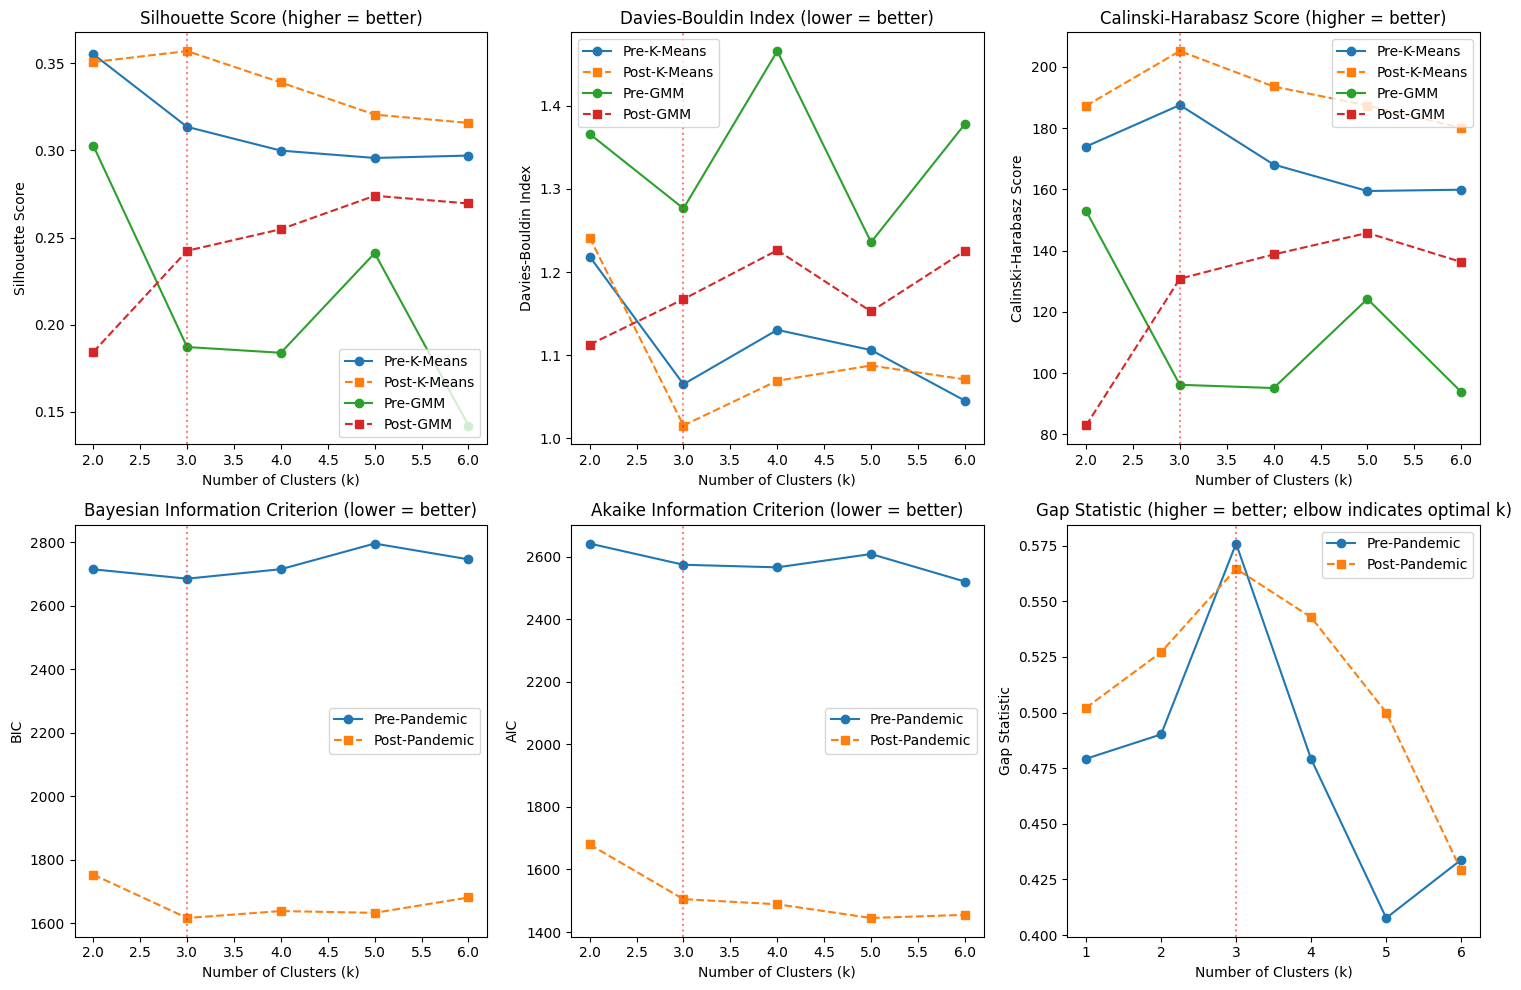

In [116]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))


ax = axes[0, 0]
for method in ['K-Means', 'GMM']:
    pre_data = df_pre[df_pre['Method'] == method]
    post_data = df_post[df_post['Method'] == method]
    ax.plot(pre_data['k'], pre_data['Silhouette'], 'o-', label=f'Pre-{method}')
    ax.plot(post_data['k'], post_data['Silhouette'], 's--', label=f'Post-{method}')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score (higher = better)')
ax.legend()
ax.axvline(x=3, color='red', linestyle=':', alpha=0.5, label='k=3')


ax = axes[0, 1]
for method in ['K-Means', 'GMM']:
    pre_data = df_pre[df_pre['Method'] == method]
    post_data = df_post[df_post['Method'] == method]
    ax.plot(pre_data['k'], pre_data['Davies-Bouldin'], 'o-', label=f'Pre-{method}')
    ax.plot(post_data['k'], post_data['Davies-Bouldin'], 's--', label=f'Post-{method}')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Davies-Bouldin Index')
ax.set_title('Davies-Bouldin Index (lower = better)')
ax.legend()
ax.axvline(x=3, color='red', linestyle=':', alpha=0.5)


ax = axes[0, 2]
for method in ['K-Means', 'GMM']:
    pre_data = df_pre[df_pre['Method'] == method]
    post_data = df_post[df_post['Method'] == method]
    ax.plot(pre_data['k'], pre_data['Calinski-Harabasz'], 'o-', label=f'Pre-{method}')
    ax.plot(post_data['k'], post_data['Calinski-Harabasz'], 's--', label=f'Post-{method}')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Calinski-Harabasz Score')
ax.set_title('Calinski-Harabasz Score (higher = better)')
ax.legend()
ax.axvline(x=3, color='red', linestyle=':', alpha=0.5)


ax = axes[1, 0]
gmm_data_pre = df_pre[df_pre['Method'] == 'GMM']
gmm_data_post = df_post[df_post['Method'] == 'GMM']
ax.plot(gmm_data_pre['k'], gmm_data_pre['BIC'], 'o-', label='Pre-Pandemic')
ax.plot(gmm_data_post['k'], gmm_data_post['BIC'], 's--', label='Post-Pandemic')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('BIC')
ax.set_title('Bayesian Information Criterion (lower = better)')
ax.legend()
ax.axvline(x=3, color='red', linestyle=':', alpha=0.5)


ax = axes[1, 1]
ax.plot(gmm_data_pre['k'], gmm_data_pre['AIC'], 'o-', label='Pre-Pandemic')
ax.plot(gmm_data_post['k'], gmm_data_post['AIC'], 's--', label='Post-Pandemic')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('AIC')
ax.set_title('Akaike Information Criterion (lower = better)')
ax.legend()
ax.axvline(x=3, color='red', linestyle=':', alpha=0.5)


ax = axes[1, 2]
ax.plot(K_range_pre, gaps_pre, 'o-', label='Pre-Pandemic')
ax.plot(K_range_post, gaps_post, 's--', label='Post-Pandemic')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Gap Statistic')
ax.set_title('Gap Statistic (higher = better; elbow indicates optimal k)')
ax.legend()
ax.axvline(x=3, color='red', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('cluster_metrics_across_k.png', dpi=300, bbox_inches='tight')
plt.show()

In [117]:
print("K-MEANS CLUSTERING (k=3)")

kmeans_pre  = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_post = KMeans(n_clusters=3, random_state=42, n_init=10)

cluster_labels_pre  = kmeans_pre.fit_predict(data_pre_scaled)
cluster_labels_post = kmeans_post.fit_predict(data_post_scaled)

centers_pre_std  = kmeans_pre.cluster_centers_
centers_post_std = kmeans_post.cluster_centers_


pre_sizes  = {i: int((cluster_labels_pre  == i).sum()) for i in range(3)}
post_sizes = {i: int((cluster_labels_post == i).sum()) for i in range(3)}

print("\nCluster Sizes:")
print(f"  Pre-Pandemic:  {pre_sizes}")
print(f"  Post-Pandemic: {post_sizes}")


print("\nPre-Pandemic Cluster Centres (Standardized) with SD:")
for i in range(3):
    mask = cluster_labels_pre == i
    cluster_data = data_pre_scaled[mask]
    means = cluster_data.mean(axis=0)
    stds = cluster_data.std(axis=0)
    print(f"  Cluster {i}: PTSS={means[0]:+.3f} ± {stds[0]:.3f}  "
          f"Coping={means[1]:+.3f} ± {stds[1]:.3f}  "
          f"Stress={means[2]:+.3f} ± {stds[2]:.3f}  (n={pre_sizes[i]})")

print("\nPost-Pandemic Cluster Centres (Standardized) with SD:")
for i in range(3):
    mask = cluster_labels_post == i
    cluster_data = data_post_scaled[mask]
    means = cluster_data.mean(axis=0)
    stds = cluster_data.std(axis=0)
    print(f"  Cluster {i}: PTSS={means[0]:+.3f} ± {stds[0]:.3f}  "
          f"Coping={means[1]:+.3f} ± {stds[1]:.3f}  "
          f"Stress={means[2]:+.3f} ± {stds[2]:.3f}  (n={post_sizes[i]})")


sil_pre  = silhouette_score(data_pre_scaled,  cluster_labels_pre)
db_pre   = davies_bouldin_score(data_pre_scaled,  cluster_labels_pre)
ch_pre   = calinski_harabasz_score(data_pre_scaled,  cluster_labels_pre)
sil_post = silhouette_score(data_post_scaled, cluster_labels_post)
db_post  = davies_bouldin_score(data_post_scaled, cluster_labels_post)
ch_post  = calinski_harabasz_score(data_post_scaled, cluster_labels_post)

print(f"\nValidation Metrics (k=3):")
print(f"  {'':30s}  {'Silhouette':>10}  {'Davies-Bouldin':>14}  {'Calinski-Harabasz':>17}")
print(f"  {'Pre-Pandemic':30s}  {sil_pre:>10.4f}  {db_pre:>14.4f}  {ch_pre:>17.2f}")
print(f"  {'Post-Pandemic':30s}  {sil_post:>10.4f}  {db_post:>14.4f}  {ch_post:>17.2f}")


print("\nOriginal Scale Cluster Means (± SD) — Pre-Pandemic:")
for i in range(3):
    mask = cluster_labels_pre == i
    means = data_pre[features][mask].mean()
    stds = data_pre[features][mask].std()
    print(f"  Cluster {i} (n={pre_sizes[i]}): "
          f"PTSS={means['PTSS Symptoms']:.2f} ± {stds['PTSS Symptoms']:.2f}  "
          f"Coping={means['Coping Strategy']:.2f} ± {stds['Coping Strategy']:.2f}  "
          f"Stress={means['Pandemic Stress']:.2f} ± {stds['Pandemic Stress']:.2f}")

print("\nOriginal Scale Cluster Means (± SD) — Post-Pandemic:")
for i in range(3):
    mask = cluster_labels_post == i
    means = data_post[features][mask].mean()
    stds = data_post[features][mask].std()
    print(f"  Cluster {i} (n={post_sizes[i]}): "
          f"PTSS={means['PTSS Symptoms']:.2f} ± {stds['PTSS Symptoms']:.2f}  "
          f"Coping={means['Coping Strategy']:.2f} ± {stds['Coping Strategy']:.2f}  "
          f"Stress={means['Pandemic Stress']:.2f} ± {stds['Pandemic Stress']:.2f}")

K-MEANS CLUSTERING (k=3)

Cluster Sizes:
  Pre-Pandemic:  {0: 135, 1: 83, 2: 120}
  Post-Pandemic: {0: 74, 1: 166, 2: 98}

Pre-Pandemic Cluster Centres (Standardized) with SD:
  Cluster 0: PTSS=-0.182 ± 0.805  Coping=-0.833 ± 0.470  Stress=-0.552 ± 0.560  (n=135)
  Cluster 1: PTSS=+1.179 ± 0.845  Coping=+0.105 ± 0.911  Stress=+1.285 ± 0.833  (n=83)
  Cluster 2: PTSS=-0.610 ± 0.472  Coping=+0.865 ± 0.677  Stress=-0.268 ± 0.655  (n=120)

Post-Pandemic Cluster Centres (Standardized) with SD:
  Cluster 0: PTSS=+1.317 ± 0.908  Coping=+0.193 ± 0.808  Stress=+1.215 ± 0.962  (n=74)
  Cluster 1: PTSS=-0.268 ± 0.707  Coping=-0.744 ± 0.471  Stress=-0.612 ± 0.484  (n=166)
  Cluster 2: PTSS=-0.541 ± 0.505  Coping=+1.114 ± 0.610  Stress=+0.120 ± 0.768  (n=98)

Validation Metrics (k=3):
                                  Silhouette  Davies-Bouldin  Calinski-Harabasz
  Pre-Pandemic                        0.3135          1.0651             187.51
  Post-Pandemic                       0.3570          1.0

In [118]:
print("CROSS-WAVE CLUSTER CORRESPONDENCE (Hungarian Algorithm)")


dist_matrix = cdist(centers_pre_std, centers_post_std, metric='euclidean')
dist_df = pd.DataFrame(
    dist_matrix,
    index   = [f'Pre-Cluster {i}' for i in range(3)],
    columns = [f'Post-Cluster {i}' for i in range(3)]
)
print("\nCentroid Distance Matrix (Euclidean):")
print(dist_df.round(4))


row_ind, col_ind = linear_sum_assignment(dist_matrix)

matched_d     = [dist_matrix[r, c] for r, c in zip(row_ind, col_ind)]
non_matched_d = [dist_matrix[i, j]
                 for i in range(3) for j in range(3)
                 if (i, j) not in zip(row_ind, col_ind)]

avg_m  = np.mean(matched_d)
avg_nm = np.mean(non_matched_d)
ratio  = avg_nm / avg_m

print("\nOptimal Matching:")
for r, c in zip(row_ind, col_ind):
    print(f"  Pre-Cluster {r} → Post-Cluster {c}  (distance: {dist_matrix[r,c]:.4f})")

print(f"\nStructural Equivalence:")
print(f"  Avg matched distance:     {avg_m:.4f}")
print(f"  Avg non-matched distance: {avg_nm:.4f}")
print(f"  Ratio:                    {ratio:.2f}x  Strong structural equivalence")

# Relabeling
post_label_mapping  = {c: r for r, c in zip(row_ind, col_ind)}
aligned_labels_post = np.array([post_label_mapping[l] for l in cluster_labels_post])

print("\nRelabeling Map (Post original → Aligned):")
for orig, aligned in sorted(post_label_mapping.items()):
    print(f"  Post-Cluster {orig} → Cluster {aligned}")


centers_post_aligned = np.zeros_like(centers_post_std)
for post_orig, aligned in post_label_mapping.items():
    centers_post_aligned[aligned] = centers_post_std[post_orig]


post_sizes_aligned = {}
for post_orig, aligned in post_label_mapping.items():
    post_sizes_aligned[aligned] = post_sizes[post_orig]

#
print("\nPost-Pandemic Cluster Centres (Standardized) AFTER ALIGNMENT with SD:")
for aligned_cluster in range(3):
    orig_cluster = [orig for orig, aligned in post_label_mapping.items() if aligned == aligned_cluster][0]
    mask = cluster_labels_post == orig_cluster
    cluster_data = data_post_scaled[mask]
    means = cluster_data.mean(axis=0)
    stds = cluster_data.std(axis=0)
    print(f"  Aligned Cluster {aligned_cluster} (original Cluster {orig_cluster}): "
          f"PTSS={means[0]:+.3f} ± {stds[0]:.3f}  "
          f"Coping={means[1]:+.3f} ± {stds[1]:.3f}  "
          f"Stress={means[2]:+.3f} ± {stds[2]:.3f}  (n={post_sizes[orig_cluster]})")


print("\nOriginal Scale Cluster Means (± SD) — Post-Pandemic (ALIGNED):")
for aligned_cluster in range(3):
    orig_cluster = [orig for orig, aligned in post_label_mapping.items() if aligned == aligned_cluster][0]
    mask = cluster_labels_post == orig_cluster
    means = data_post[features][mask].mean()
    stds = data_post[features][mask].std()
    print(f"  Aligned Cluster {aligned_cluster} (original Cluster {orig_cluster}, n={post_sizes[orig_cluster]}): "
          f"PTSS={means['PTSS Symptoms']:.2f} ± {stds['PTSS Symptoms']:.2f}  "
          f"Coping={means['Coping Strategy']:.2f} ± {stds['Coping Strategy']:.2f}  "
          f"Stress={means['Pandemic Stress']:.2f} ± {stds['Pandemic Stress']:.2f}")

CROSS-WAVE CLUSTER CORRESPONDENCE (Hungarian Algorithm)

Centroid Distance Matrix (Euclidean):
               Post-Cluster 0  Post-Cluster 1  Post-Cluster 2
Pre-Cluster 0          2.5343          0.1376          2.0910
Pre-Cluster 1          0.1791          2.5318          2.3098
Pre-Cluster 2          2.5231          1.6808          0.4661

Optimal Matching:
  Pre-Cluster 0 → Post-Cluster 1  (distance: 0.1376)
  Pre-Cluster 1 → Post-Cluster 0  (distance: 0.1791)
  Pre-Cluster 2 → Post-Cluster 2  (distance: 0.4661)

Structural Equivalence:
  Avg matched distance:     0.2609
  Avg non-matched distance: 2.2785
  Ratio:                    8.73x  Strong structural equivalence

Relabeling Map (Post original → Aligned):
  Post-Cluster 0 → Cluster 1
  Post-Cluster 1 → Cluster 0
  Post-Cluster 2 → Cluster 2

Post-Pandemic Cluster Centres (Standardized) AFTER ALIGNMENT with SD:
  Aligned Cluster 0 (original Cluster 1): PTSS=-0.268 ± 0.707  Coping=-0.744 ± 0.471  Stress=-0.612 ± 0.484  (n=166)
 

In [119]:
from sklearn.utils import resample
from sklearn.metrics import adjusted_rand_score

def bootstrap_cluster_stability(data, n_clusters=3, n_bootstrap=100, random_state=42):
    """
    Bootstrap stability of K‑Means clustering using Adjusted Rand Index.
    
    Parameters:
        data (np.ndarray): Standardized feature matrix (samples × features)
        n_clusters (int): Number of clusters
        n_bootstrap (int): Number of bootstrap iterations
        random_state (int): Seed for reproducibility
    
    Returns:
        dict with 'mean_ari', 'ci_lower', 'ci_upper', and list of 'ari_scores'
    """
    np.random.seed(random_state)
    
    # Original clustering on full data
    kmeans_orig = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels_orig = kmeans_orig.fit_predict(data)
    
    ari_scores = []
    for i in range(n_bootstrap):
        # Bootstrap sample (with replacement) of the same size
        boot_idx = np.random.choice(len(data), size=len(data), replace=True)
        data_boot = data[boot_idx]
        
        # Cluster bootstrap sample
        kmeans_boot = KMeans(n_clusters=n_clusters, random_state=random_state + i, n_init=10)
        labels_boot = kmeans_boot.fit_predict(data_boot)
        
        # Compute ARI between bootstrap labels and original labels (only on sampled indices)
        ari = adjusted_rand_score(labels_orig[boot_idx], labels_boot)
        ari_scores.append(ari)
    
    mean_ari = np.mean(ari_scores)
    ci_lower = np.percentile(ari_scores, 2.5)
    ci_upper = np.percentile(ari_scores, 97.5)
    
    return {'mean_ari': mean_ari, 'ci_lower': ci_lower, 'ci_upper': ci_upper, 'scores': ari_scores}


# --- Run bootstrap stability analysis for both waves ---
print("\n" + "="*60)
print("BOOTSTRAP CLUSTER STABILITY (Adjusted Rand Index)")
print("="*60)

stability_pre = bootstrap_cluster_stability(data_pre_scaled, n_clusters=3, n_bootstrap=100)
print(f"\nWave 1 (Pre‑pandemic):")
print(f"  Mean ARI = {stability_pre['mean_ari']:.4f}")
print(f"  95% CI   = [{stability_pre['ci_lower']:.4f}, {stability_pre['ci_upper']:.4f}]")

stability_post = bootstrap_cluster_stability(data_post_scaled, n_clusters=3, n_bootstrap=100)
print(f"\nWave 2 (Post‑pandemic):")
print(f"  Mean ARI = {stability_post['mean_ari']:.4f}")
print(f"  95% CI   = [{stability_post['ci_lower']:.4f}, {stability_post['ci_upper']:.4f}]")

# Optional interpretation
if stability_pre['ci_lower'] > 0.7 and stability_post['ci_lower'] > 0.7:
    print("\n✓ High cluster stability (ARI > 0.7) – centroids are robust to sampling variability.")
else:
    print("\n⚠ Moderate/low stability – consider increasing bootstrap iterations or checking cluster separation.")


BOOTSTRAP CLUSTER STABILITY (Adjusted Rand Index)

Wave 1 (Pre‑pandemic):
  Mean ARI = 0.9127
  95% CI   = [0.7859, 1.0000]

Wave 2 (Post‑pandemic):
  Mean ARI = 0.7743
  95% CI   = [0.5946, 0.9222]

⚠ Moderate/low stability – consider increasing bootstrap iterations or checking cluster separation.


In [120]:
print("CLINICAL PROFILE NAMING")

PROFILE_ORDER = ['Resilient', 'Moderate-Distress', 'High-Distress']

def assign_profile(ptss, coping, stress):
    if ptss > 0.5 and stress > 0.5:
        return "High-Distress"
    elif ptss < 0 and coping > 0.4:
        return "Resilient"
    elif coping < -0.4:
        return "Moderate-Distress"
    else:
        return "REVIEW"


profile_names_pre = {
    i: assign_profile(centers_pre_std[i][0],
                      centers_pre_std[i][1],
                      centers_pre_std[i][2])
    for i in range(3)
}

profile_names_post = {
    i: assign_profile(centers_post_aligned[i][0],
                      centers_post_aligned[i][1],
                      centers_post_aligned[i][2])
    for i in range(3)
}

print("\nWave 1 Profiles:")
for i in range(3):
    c = centers_pre_std[i]
    print(f"  Cluster {i}: {profile_names_pre[i]}")
    print(f"    PTSS={c[0]:+.3f}  Coping={c[1]:+.3f}  Stress={c[2]:+.3f}")

print("\nWave 2 Profiles — after alignment:")
for i in range(3):
    c = centers_post_aligned[i]
    print(f"  Cluster {i}: {profile_names_post[i]}")
    print(f"    PTSS={c[0]:+.3f}  Coping={c[1]:+.3f}  Stress={c[2]:+.3f}")


pre_set  = set(profile_names_pre.values())
post_set = set(profile_names_post.values())
if pre_set == post_set == set(PROFILE_ORDER):
    print("\n Profile names consistent and correct across both waves")
else:
    print(f"\n  Pre:  {pre_set}")
    print(f"  Post: {post_set}")


data_pre_prof  = data_pre.copy()
data_post_prof = data_post.copy()

data_pre_prof['Cluster']  = cluster_labels_pre
data_pre_prof['Profile']  = data_pre_prof['Cluster'].map(profile_names_pre)

data_post_prof['Cluster_Original'] = cluster_labels_post
data_post_prof['Cluster_Aligned']  = aligned_labels_post
data_post_prof['Profile']          = data_post_prof['Cluster_Aligned'].map(profile_names_post)

print("\nWave 1 Profile Distribution:")
for p in PROFILE_ORDER:
    n = (data_pre_prof['Profile'] == p).sum()
    print(f"  {p}: n={n} ({n/len(data_pre_prof)*100:.1f}%)")

print("\nWave 2 Profile Distribution (aligned):")
for p in PROFILE_ORDER:
    n = (data_post_prof['Profile'] == p).sum()
    print(f"  {p}: n={n} ({n/len(data_post_prof)*100:.1f}%)")

CLINICAL PROFILE NAMING

Wave 1 Profiles:
  Cluster 0: Moderate-Distress
    PTSS=-0.182  Coping=-0.833  Stress=-0.552
  Cluster 1: High-Distress
    PTSS=+1.179  Coping=+0.105  Stress=+1.285
  Cluster 2: Resilient
    PTSS=-0.610  Coping=+0.865  Stress=-0.268

Wave 2 Profiles — after alignment:
  Cluster 0: Moderate-Distress
    PTSS=-0.268  Coping=-0.744  Stress=-0.612
  Cluster 1: High-Distress
    PTSS=+1.317  Coping=+0.193  Stress=+1.215
  Cluster 2: Resilient
    PTSS=-0.541  Coping=+1.114  Stress=+0.120

 Profile names consistent and correct across both waves

Wave 1 Profile Distribution:
  Resilient: n=120 (35.5%)
  Moderate-Distress: n=135 (39.9%)
  High-Distress: n=83 (24.6%)

Wave 2 Profile Distribution (aligned):
  Resilient: n=98 (29.0%)
  Moderate-Distress: n=166 (49.1%)
  High-Distress: n=74 (21.9%)


In [121]:
def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    margin = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return (max(0.0, center - margin)*100, min(100.0, center + margin)*100)

print("TRANSITION MATRIX & STABILITY")

df_long = data_pre_prof[['Profile', 'Age', 'Gender', 'Level of Education', 'Work Status']].copy()
df_long['Profile_Wave2'] = data_post_prof['Profile'].values

transition_counts = pd.crosstab(
    df_long['Profile'],
    df_long['Profile_Wave2']
).reindex(index=PROFILE_ORDER, columns=PROFILE_ORDER, fill_value=0)

transition_pct = pd.crosstab(
    df_long['Profile'],
    df_long['Profile_Wave2'],
    normalize='index'
).reindex(index=PROFILE_ORDER, columns=PROFILE_ORDER, fill_value=0) * 100

print("\nTransition Matrix — Counts (row=Wave1, col=Wave2):")
print(transition_counts.to_string())

print("\nTransition Matrix — Percentages:")
print(transition_pct.round(1).to_string())

print(f"\n{'Profile':<35} {'Wave1 n':>8} {'Stable':>7} {'%':>7} {'95% CI':>18}")
print("-" * 78)

total_stable = 0
for p in PROFILE_ORDER:
    n1  = int(transition_counts.loc[p].sum())
    ns  = int(transition_counts.loc[p, p])
    pct = ns / n1 * 100 if n1 else 0
    lo, hi = wilson_ci(ns, n1)
    total_stable += ns
    print(f"{p:<35} {n1:>8} {ns:>7} {pct:>6.1f}%  [{lo:.1f}%, {hi:.1f}%]")

nt = len(df_long)
op = total_stable / nt * 100
lo_all, hi_all = wilson_ci(total_stable, nt)
print("-" * 78)
print(f"{'Overall':<35} {nt:>8} {total_stable:>7} {op:>6.1f}%  [{lo_all:.1f}%, {hi_all:.1f}%]")

TRANSITION MATRIX & STABILITY

Transition Matrix — Counts (row=Wave1, col=Wave2):
Profile_Wave2      Resilient  Moderate-Distress  High-Distress
Profile                                                       
Resilient                 53                 48             19
Moderate-Distress         28                 93             14
High-Distress             17                 25             41

Transition Matrix — Percentages:
Profile_Wave2      Resilient  Moderate-Distress  High-Distress
Profile                                                       
Resilient               44.2               40.0           15.8
Moderate-Distress       20.7               68.9           10.4
High-Distress           20.5               30.1           49.4

Profile                              Wave1 n  Stable       %             95% CI
------------------------------------------------------------------------------
Resilient                                120      53   44.2%  [35.6%, 53.1%]
Moderate-Distress

In [122]:
print("INCOME AS PREDICTOR OF TRANSITIONS")


income_recode_3cat = {
    4: 'High Income',
    3: 'Middle Income',
    2: 'Middle Income',
    1: 'Low Income'
}
income_order_3cat = ['High Income', 'Middle Income', 'Low Income']


df_long['Income_Group'] = data_pre['Country Income Profile'].map(income_recode_3cat)


df_long['Deteriorated_from_Resilient'] = ((df_long['Profile'] == 'Resilient') & 
                                           (df_long['Profile_Wave2'] != 'Resilient')).astype(int)

df_long['Improved_from_HighDistress'] = ((df_long['Profile'] == 'High-Distress') & 
                                          (df_long['Profile_Wave2'] != 'High-Distress')).astype(int)

df_long['Stable_Moderate'] = ((df_long['Profile'] == 'Moderate-Distress') & 
                               (df_long['Profile_Wave2'] == 'Moderate-Distress')).astype(int)

def run_logistic_3cat(df_sub, outcome_col, label, ref_income='Low Income', target_income='High Income'):
    df_sub = df_sub.copy()
    df_sub = df_sub[df_sub['Income_Group'].isin([ref_income, target_income])]
    df_sub['Income_Binary'] = (df_sub['Income_Group'] == target_income).astype(int)
    
    if df_sub['Income_Binary'].nunique() < 2 or df_sub[outcome_col].nunique() < 2:
        print(f"  {label}: Insufficient variation for logistic regression")
        return None, None, None
    
    ct = pd.crosstab(df_sub['Income_Group'], df_sub[outcome_col])
    if ct.shape[1] == 2:
        chi2, p_chi2, _, _ = chi2_contingency(ct)
        print(f"\n  {label}:")
        print(f"  Chi-square: χ²={chi2:.2f}, p={p_chi2:.4f}")
    
    try:
        X = sm.add_constant(df_sub[['Income_Binary']])
        model = Logit(df_sub[outcome_col], X).fit(disp=0)
        OR  = np.exp(model.params['Income_Binary'])
        CI  = np.exp(model.conf_int().loc['Income_Binary'])
        p   = model.pvalues['Income_Binary']
        print(f"  OR={OR:.2f}, 95% CI [{CI[0]:.2f}, {CI[1]:.2f}], p={p:.4f}")
        return OR, CI, p
    except Exception as e:
        print(f"  Logistic regression failed: {e}")
        return None, None, None


print("ANALYSIS 1: Predictors of Deterioration from Resilient Profile")


resilient_df = df_long[df_long['Profile'] == 'Resilient'].copy()
print(f"\nResilient participants at Wave 1: n={len(resilient_df)}")
print(f"  Stable (remained Resilient): {(resilient_df['Profile_Wave2'] == 'Resilient').sum()}")
print(f"  Deteriorated: {(resilient_df['Profile_Wave2'] != 'Resilient').sum()}")

ct_resilient = pd.crosstab(resilient_df['Income_Group'], resilient_df['Deteriorated_from_Resilient'])
ct_resilient = ct_resilient.reindex(index=income_order_3cat, fill_value=0)
print("\nDeterioration from Resilient by Income Group:")
print(ct_resilient)

if ct_resilient.shape[1] >= 2 and ct_resilient.sum().sum() > 0:
    chi2_res, p_res, dof_res, exp_res = chi2_contingency(ct_resilient)
    print(f"\nChi-square test (3x2): χ²={chi2_res:.2f}, p={p_res:.4f}")

OR_resilient, CI_resilient, p_resilient = run_logistic_3cat(
    resilient_df, 'Deteriorated_from_Resilient',
    "Deterioration from Resilient (High vs Low Income)",
    ref_income='Low Income', target_income='High Income'
)


print("ANALYSIS 2: Predictors of Improvement from High-Distress Profile")


highdistress_df = df_long[df_long['Profile'] == 'High-Distress'].copy()
print(f"\nHigh-Distress participants at Wave 1: n={len(highdistress_df)}")
print(f"  Stable (remained High-Distress): {(highdistress_df['Profile_Wave2'] == 'High-Distress').sum()}")
print(f"  Improved: {(highdistress_df['Profile_Wave2'] != 'High-Distress').sum()}")

ct_hd = pd.crosstab(highdistress_df['Income_Group'], highdistress_df['Improved_from_HighDistress'])
ct_hd = ct_hd.reindex(index=income_order_3cat, fill_value=0)
print("\nImprovement from High-Distress by Income Group:")
print(ct_hd)

if ct_hd.shape[1] >= 2 and ct_hd.sum().sum() > 0:
    chi2_hd, p_hd, dof_hd, exp_hd = chi2_contingency(ct_hd)
    print(f"\nChi-square test: χ²={chi2_hd:.2f}, p={p_hd:.4f}")

OR_hd, CI_hd, p_hd_logistic = run_logistic_3cat(
    highdistress_df, 'Improved_from_HighDistress',
    "Improvement from High-Distress (High vs Low Income)",
    ref_income='Low Income', target_income='High Income'
)


print("ANALYSIS 3: Predictors of Stability in Moderate-Distress")


moderate_df = df_long[df_long['Profile'] == 'Moderate-Distress'].copy()
print(f"\nModerate participants at Wave 1: n={len(moderate_df)}")
print(f"  Stable: {(moderate_df['Profile_Wave2'] == 'Moderate-Distress').sum()}")
print(f"  Changed: {(moderate_df['Profile_Wave2'] != 'Moderate-Distress').sum()}")

ct_mod = pd.crosstab(moderate_df['Income_Group'], moderate_df['Stable_Moderate'])
ct_mod = ct_mod.reindex(index=income_order_3cat, fill_value=0)
print("\nStability in Moderate Profile by Income Group:")
print(ct_mod)

if ct_mod.shape[1] >= 2 and ct_mod.sum().sum() > 0:
    chi2_mod, p_mod, dof_mod, exp_mod = chi2_contingency(ct_mod)
    print(f"\nChi-square test: χ²={chi2_mod:.2f}, p={p_mod:.4f}")

OR_moderate, CI_moderate, p_moderate = run_logistic_3cat(
    moderate_df, 'Stable_Moderate',
    "Stability in Moderate (Low vs High Income)",
    ref_income='High Income', target_income='Low Income'
)


INCOME AS PREDICTOR OF TRANSITIONS
ANALYSIS 1: Predictors of Deterioration from Resilient Profile

Resilient participants at Wave 1: n=120
  Stable (remained Resilient): 53
  Deteriorated: 67

Deterioration from Resilient by Income Group:
Deteriorated_from_Resilient   0   1
Income_Group                       
High Income                   8  10
Middle Income                14  16
Low Income                   31  41

Chi-square test (3x2): χ²=0.11, p=0.9452

  Deterioration from Resilient (High vs Low Income):
  Chi-square: χ²=0.00, p=1.0000
  OR=0.95, 95% CI [0.33, 2.67], p=0.9153
ANALYSIS 2: Predictors of Improvement from High-Distress Profile

High-Distress participants at Wave 1: n=83
  Stable (remained High-Distress): 41
  Improved: 42

Improvement from High-Distress by Income Group:
Improved_from_HighDistress   0   1
Income_Group                      
High Income                 13  10
Middle Income               13  14
Low Income                  15  18

Chi-square test: χ²=0.69,

In [123]:
print("SUMMARY: ODDS RATIOS FROM LOGISTIC REGRESSION")
print("\n| Outcome | Comparison | OR | 95% CI | p-value |")
print("|---------|------------|----|--------|---------|")

if OR_resilient is not None:
    print(f"| Deterioration from Resilient | High vs Low Income | {OR_resilient:.2f} | [{CI_resilient[0]:.2f}, {CI_resilient[1]:.2f}] | {p_resilient:.4f} |")
else:
    print("| Deterioration from Resilient | High vs Low Income | Not calculated | - | - |")

if OR_hd is not None:
    print(f"| Improvement from High-Distress | High vs Low Income | {OR_hd:.2f} | [{CI_hd[0]:.2f}, {CI_hd[1]:.2f}] | {p_hd_logistic:.4f} |")
else:
    print("| Improvement from High-Distress | High vs Low Income | Not calculated | - | - |")

if OR_moderate is not None:
    print(f"| Stability in Moderate | Low vs High Income | {OR_moderate:.2f} | [{CI_moderate[0]:.2f}, {CI_moderate[1]:.2f}] | {p_moderate:.4f} |")
else:
    print("| Stability in Moderate | Low vs High Income | Not calculated | - | - |")



SUMMARY: ODDS RATIOS FROM LOGISTIC REGRESSION

| Outcome | Comparison | OR | 95% CI | p-value |
|---------|------------|----|--------|---------|
| Deterioration from Resilient | High vs Low Income | 0.95 | [0.33, 2.67] | 0.9153 |
| Improvement from High-Distress | High vs Low Income | 0.64 | [0.22, 1.87] | 0.4162 |
| Stability in Moderate | Low vs High Income | 1.92 | [0.42, 8.75] | 0.3993 |


In [124]:
print("DEMOGRAPHIC ANALYSIS BY CLINICAL PROFILE")

def cramers_v(chi2, n, r, c):
    k = min(r - 1, c - 1)
    if k == 0:
        return 0.0
    return np.sqrt(chi2 / (n * k))

def cohens_d(m1, s1, n1, m2, s2, n2):
    pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    return abs(m1 - m2) / pooled if pooled > 0 else 0

def interpret_v(v):
    if v < 0.10: return "negligible"
    if v < 0.30: return "small"
    if v < 0.50: return "medium"
    return "large"

def interpret_d(d):
    if d < 0.20: return "negligible"
    if d < 0.50: return "small"
    if d < 0.80: return "medium"
    return "large"

def interpret_eta(e):
    if e < 0.01: return "negligible"
    if e < 0.06: return "small"
    if e < 0.14: return "medium"
    return "large"

def run_demographic_analysis(df, label):
    print(f"\n{'─'*60}")
    print(f"  {label}")
    print(f"{'─'*60}")

    for col in ['Gender', 'Level of Education', 'Work Status']:
        if col not in df.columns:
            continue
        ct = pd.crosstab(df['Profile'], df[col]).reindex(
            index=PROFILE_ORDER, fill_value=0)
        chi2, p, dof, exp = chi2_contingency(ct)
        n = len(df)
        v = cramers_v(chi2, n, ct.shape[0], ct.shape[1])
        print(f"\n  {col}:")
        print(ct.to_string())
        print(f"  χ²={chi2:.2f}, df={dof}, p={p:.4f}, V={v:.3f} ({interpret_v(v)})")

        exp_df = pd.DataFrame(exp, index=ct.index, columns=ct.columns)
        if (exp_df < 5).any().any():
            print("Some expected frequencies < 5")
        else:
            print("All expected frequencies > 5")

    if 'Age' not in df.columns:
        return

    print(f"\n  Age:")
    groups = []
    age_stats = {}
    for p in PROFILE_ORDER:
        ages = df[df['Profile'] == p]['Age'].dropna()
        if len(ages) == 0:
            continue
        boots = [np.mean(resample(ages.values)) for _ in range(1000)]
        ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
        age_stats[p] = {'mean': ages.mean(), 'std': ages.std(),
                        'n': len(ages), 'ci': (ci_lo, ci_hi)}
        groups.append(ages)
        print(f"    {p}: {ages.mean():.1f} ± {ages.std():.1f}  "
              f"95% CI [{ci_lo:.1f}, {ci_hi:.1f}]  n={len(ages)}")

    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        df_between = len(groups) - 1
        df_within  = len(df['Age'].dropna()) - len(groups)
        eta_sq = (f_stat * df_between) / (f_stat * df_between + df_within)
        print(f"\n    ANOVA: F={f_stat:.3f}, p={p_val:.4f}, "
              f"η²={eta_sq:.4f} ({interpret_eta(eta_sq)})")

        if p_val < 0.05:
            profiles_with_data = [p for p in PROFILE_ORDER if p in age_stats]
            print("    Post-hoc Cohen's d:")
            for i in range(len(profiles_with_data)):
                for j in range(i+1, len(profiles_with_data)):
                    p1, p2 = profiles_with_data[i], profiles_with_data[j]
                    d = cohens_d(age_stats[p1]['mean'], age_stats[p1]['std'],
                                 age_stats[p1]['n'],
                                 age_stats[p2]['mean'], age_stats[p2]['std'],
                                 age_stats[p2]['n'])
                    print(f"      {p1} vs {p2}: d={d:.3f} ({interpret_d(d)})")

run_demographic_analysis(data_pre_prof,  "Wave 1 (Pre-Pandemic)")
run_demographic_analysis(data_post_prof, "Wave 2 (Post-Pandemic)")

DEMOGRAPHIC ANALYSIS BY CLINICAL PROFILE

────────────────────────────────────────────────────────────
  Wave 1 (Pre-Pandemic)
────────────────────────────────────────────────────────────

  Gender:
Gender              1   2
Profile                  
Resilient          54  66
Moderate-Distress  66  69
High-Distress      32  51
  χ²=2.22, df=2, p=0.3298, V=0.081 (negligible)
All expected frequencies > 5

  Level of Education:
Level of Education  1   2   3   4
Profile                          
Resilient           0  11  48  61
Moderate-Distress   1  15  85  34
High-Distress       0  12  43  28
  χ²=20.86, df=6, p=0.0019, V=0.176 (small)
Some expected frequencies < 5

  Work Status:
Work Status         1   2
Profile                  
Resilient          91  29
Moderate-Distress  84  51
High-Distress      41  42
  χ²=15.14, df=2, p=0.0005, V=0.212 (small)
All expected frequencies > 5

  Age:
    Resilient: 42.8 ± 13.0  95% CI [40.4, 45.1]  n=120
    Moderate-Distress: 37.4 ± 11.0  95% CI [3

In [125]:
print("COUNTRY INCOME LEVEL DISTRIBUTION BY CLINICAL PROFILE")

data_pre_prof['Income_Group'] = data_pre['Country Income Profile'].map(income_recode_3cat)
data_post_prof['Income_Group'] = data_post['Country Income Profile'].map(income_recode_3cat)

def run_income_analysis_cross(df, label):
    print(f"\n{label}:")
    ct = pd.crosstab(df['Income_Group'], df['Profile'])\
           .reindex(index=income_order_3cat, columns=PROFILE_ORDER, fill_value=0)
    print(ct)

    if ct.sum().sum() > 0 and ct.shape[1] >= 2 and ct.shape[0] >= 2:
        chi2, p, dof, exp = chi2_contingency(ct)
        n = len(df)
        # CORRECTED: pass rows and columns to cramers_v
        v = cramers_v(chi2, n, ct.shape[0], ct.shape[1])
        exp_df = pd.DataFrame(exp, index=income_order_3cat, columns=PROFILE_ORDER)

        print(f"\n  χ²={chi2:.2f}, df={dof}, p={p:.4f}, V={v:.3f} ({interpret_v(v)})")

        if (exp_df < 5).any().any():
            print("Some expected frequencies < 5")
            print(exp_df.round(1))
        else:
            print("All expected frequencies > 5")

        print("\n Row percentages (% of income group in each profile):")
        print((ct.div(ct.sum(axis=1), axis=0)*100).round(1))
        return chi2, p, v
    else:
        print("\n Insufficient data for chi-square test")
        return None, None, None

chi2_pre_inc, p_pre_inc, v_pre_inc = run_income_analysis_cross(data_pre_prof, "Wave 1")
chi2_post_inc, p_post_inc, v_post_inc = run_income_analysis_cross(data_post_prof, "Wave 2")

if chi2_pre_inc is not None:
    print(f"\nSummary:")
    print(f"  Pre-Wave:  χ²={chi2_pre_inc:.2f}, p={p_pre_inc:.4f}, V={v_pre_inc:.3f}")
    print(f"  Post-Wave: χ²={chi2_post_inc:.2f}, p={p_post_inc:.4f}, V={v_post_inc:.3f}")

COUNTRY INCOME LEVEL DISTRIBUTION BY CLINICAL PROFILE

Wave 1:
Profile        Resilient  Moderate-Distress  High-Distress
Income_Group                                              
High Income           18                  8             23
Middle Income         30                 43             27
Low Income            72                 84             33

  χ²=23.38, df=4, p=0.0001, V=0.186 (small)
All expected frequencies > 5

 Row percentages (% of income group in each profile):
Profile        Resilient  Moderate-Distress  High-Distress
Income_Group                                              
High Income         36.7               16.3           46.9
Middle Income       30.0               43.0           27.0
Low Income          38.1               44.4           17.5

Wave 2:
Profile        Resilient  Moderate-Distress  High-Distress
Income_Group                                              
High Income           18                 12             14
Middle Income         29        

In [126]:
print("TRAJECTORY CLASS ANALYSIS")


def get_trajectory_class(row):
    pre = row['Profile']
    post = row['Profile_Wave2']
    
    if pre == 'Resilient' and post == 'Resilient':
        return 'Stable Resilient'
    elif pre == 'Resilient' and post != 'Resilient':
        return 'Deteriorated'
    elif pre == 'Moderate-Distress' and post == 'Moderate-Distress':
        return 'Stable Moderate'
    elif pre == 'High-Distress' and post == 'High-Distress':
        return 'Stable High-Distress'
    elif (pre in ['Moderate-Distress', 'High-Distress']) and post == 'Resilient':
        return 'Improved'
    else:
        return 'Other'

df_long['Trajectory'] = df_long.apply(get_trajectory_class, axis=1)

TRAJECTORY_ORDER = ['Stable Resilient', 'Deteriorated', 'Stable Moderate', 'Improved', 'Stable High-Distress']
TRAJECTORY_COLORS = {
    'Stable Resilient': '#2ECC71',
    'Deteriorated': '#F39C12',
    'Stable Moderate': '#3498DB',
    'Improved': '#1ABC9C',
    'Stable High-Distress': '#E74C3C'
}

print("\nTrajectory Class Sizes:")
for t in TRAJECTORY_ORDER:
    n = (df_long['Trajectory'] == t).sum()
    print(f"  {t}: n={n} ({n/len(df_long)*100:.1f}%)")
n_other = (df_long['Trajectory'] == 'Other').sum()
print(f"  Other (mixed transitions): n={n_other} ({n_other/len(df_long)*100:.1f}%)")

traj_df = df_long[df_long['Trajectory'].isin(TRAJECTORY_ORDER)].copy()

def traj_chi2(col, df=traj_df):
    ct = pd.crosstab(df['Trajectory'], df[col])\
           .reindex(index=TRAJECTORY_ORDER, fill_value=0)
    chi2, p, dof, _ = chi2_contingency(ct)
    v = cramers_v(chi2, len(df), ct.shape[0], ct.shape[1])
    print(ct.to_string())
    print(f"\n  χ²={chi2:.2f}, df={dof}, p={p:.4f}, V={v:.3f} ({interpret_v(v)})")
    return chi2, p, v

print("-"*60)
print("Age by Trajectory Class:")
print("-"*60)

age_groups_traj = []
age_stats_traj = {}
for t in TRAJECTORY_ORDER:
    ages = traj_df[traj_df['Trajectory'] == t]['Age'].dropna()
    if len(ages) > 0:
        boots = [np.mean(resample(ages.values)) for _ in range(1000)]
        ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
        age_stats_traj[t] = {'mean': ages.mean(), 'std': ages.std(), 'n': len(ages)}
        age_groups_traj.append(ages)
        print(f"  {t}: {ages.mean():.1f} ± {ages.std():.1f}  "
              f"95% CI [{ci_lo:.1f}, {ci_hi:.1f}]  n={len(ages)}")

if len(age_groups_traj) >= 2:
    f_stat, p_val = f_oneway(*age_groups_traj)
    dfb = len(age_groups_traj) - 1
    dfw = sum(len(g) for g in age_groups_traj) - len(age_groups_traj)
    eta = (f_stat * dfb) / (f_stat * dfb + dfw)
    print(f"\n  ANOVA: F={f_stat:.3f}, p={p_val:.4f}, η²={eta:.4f} ({interpret_eta(eta)})")

    if p_val < 0.05:
        ts = list(age_stats_traj.keys())
        print("  Post-hoc Cohen's d:")
        for i in range(len(ts)):
            for j in range(i+1, len(ts)):
                t1, t2 = ts[i], ts[j]
                d = cohens_d(age_stats_traj[t1]['mean'], age_stats_traj[t1]['std'], age_stats_traj[t1]['n'],
                             age_stats_traj[t2]['mean'], age_stats_traj[t2]['std'], age_stats_traj[t2]['n'])
                print(f"    {t1} vs {t2}: d={d:.3f} ({interpret_d(d)})")


print("-"*60)
print("Gender by Trajectory Class:")
print("-"*60)
traj_chi2('Gender')


print("-"*60)
print("Education by Trajectory Class:")
print("-"*60)
traj_chi2('Level of Education')

print("-"*60)
print("Work Status by Trajectory Class:")
print("-"*60)
traj_chi2('Work Status')

print("-"*60)
print("Country Income by Trajectory Class:")
print("-"*60)
ct_inc_traj = pd.crosstab(traj_df['Trajectory'], traj_df['Income_Group'])\
                .reindex(index=TRAJECTORY_ORDER, columns=income_order_3cat, fill_value=0)
print(ct_inc_traj.to_string())

if ct_inc_traj.sum().sum() > 0:
    chi2_it, p_it, dof_it, _ = chi2_contingency(ct_inc_traj)
    # CORRECTED: pass rows and columns to cramers_v
    v_it = cramers_v(chi2_it, len(traj_df), ct_inc_traj.shape[0], ct_inc_traj.shape[1])
    print(f"\n  χ²={chi2_it:.2f}, df={dof_it}, p={p_it:.4f}, V={v_it:.3f} ({interpret_v(v_it)})")

    print("\n  Row percentages (% within trajectory class):")
    print((ct_inc_traj.div(ct_inc_traj.sum(axis=1), axis=0)*100).round(1))


TRAJECTORY CLASS ANALYSIS

Trajectory Class Sizes:
  Stable Resilient: n=53 (15.7%)
  Deteriorated: n=67 (19.8%)
  Stable Moderate: n=93 (27.5%)
  Improved: n=45 (13.3%)
  Stable High-Distress: n=41 (12.1%)
  Other (mixed transitions): n=39 (11.5%)
------------------------------------------------------------
Age by Trajectory Class:
------------------------------------------------------------
  Stable Resilient: 44.6 ± 12.9  95% CI [41.2, 48.4]  n=53
  Deteriorated: 41.3 ± 13.0  95% CI [38.5, 44.2]  n=67
  Stable Moderate: 37.6 ± 10.8  95% CI [35.5, 39.8]  n=93
  Improved: 40.0 ± 11.9  95% CI [36.8, 43.5]  n=45
  Stable High-Distress: 33.3 ± 10.3  95% CI [30.2, 36.4]  n=41

  ANOVA: F=6.360, p=0.0001, η²=0.0796 (medium)
  Post-hoc Cohen's d:
    Stable Resilient vs Deteriorated: d=0.252 (small)
    Stable Resilient vs Stable Moderate: d=0.606 (medium)
    Stable Resilient vs Improved: d=0.371 (small)
    Stable Resilient vs Stable High-Distress: d=0.957 (large)
    Deteriorated vs Stab

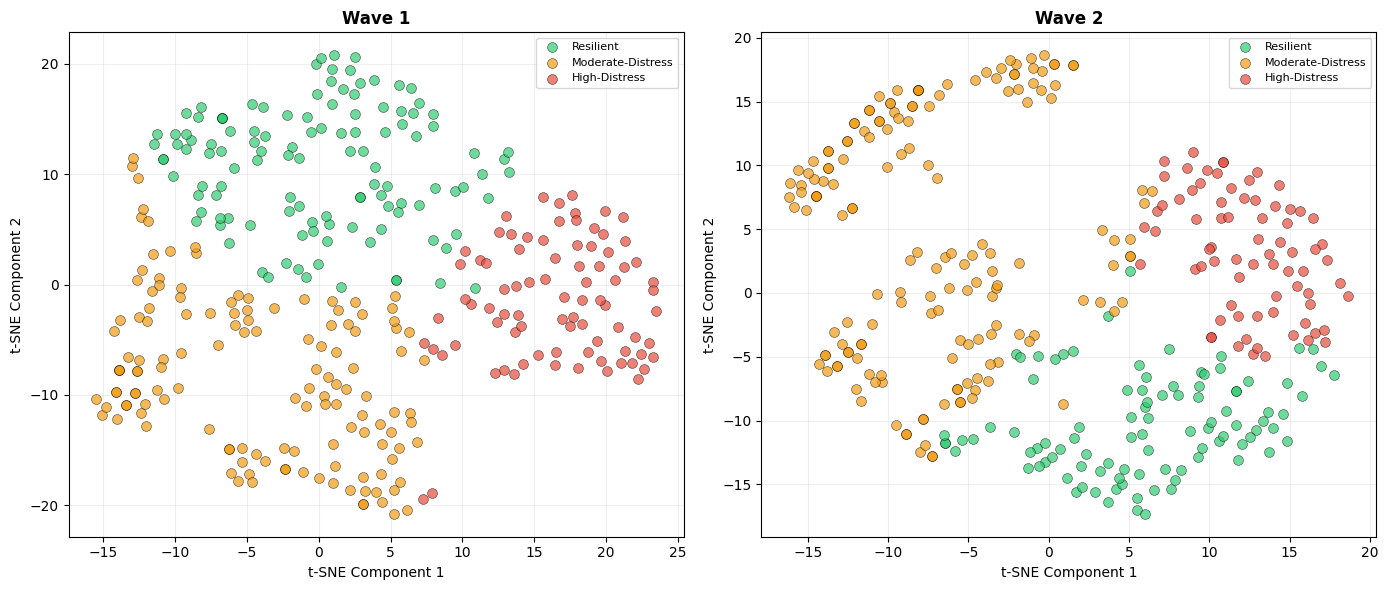

Figure 1: t-SNE saved


In [127]:
PROFILE_COLORS = {
    'Resilient': '#2ECC71',
    'Moderate-Distress': '#F39C12',
    'High-Distress': '#E74C3C',
}

SHORT_NAMES = {
    'Resilient': 'Resilient',
    'Moderate-Distress': 'Moderate',
    'High-Distress': 'High-Distress',
}

tsne_pre  = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_post = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_pre_tsne  = tsne_pre.fit_transform(data_pre_scaled)
X_post_tsne = tsne_post.fit_transform(data_post_scaled)

pre_colors  = [PROFILE_COLORS[profile_names_pre[l]]  for l in cluster_labels_pre]
post_colors = [PROFILE_COLORS[profile_names_post[post_label_mapping[l]]] for l in cluster_labels_post]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, X, colors, title in [
    (axes[0], X_pre_tsne,  pre_colors,  'Wave 1'),
    (axes[1], X_post_tsne, post_colors, 'Wave 2'),
]:
    for profile, color in PROFILE_COLORS.items():
        mask = np.array(colors) == color
        ax.scatter(X[mask, 0], X[mask, 1], c=color, label=profile,
                   alpha=0.7, edgecolors='k', linewidth=0.4, s=50)
    ax.set_title(f'{title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2)
# plt.suptitle('t-SNE Cluster Visualization by Clinical Profile', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_tsne.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 1: t-SNE saved")

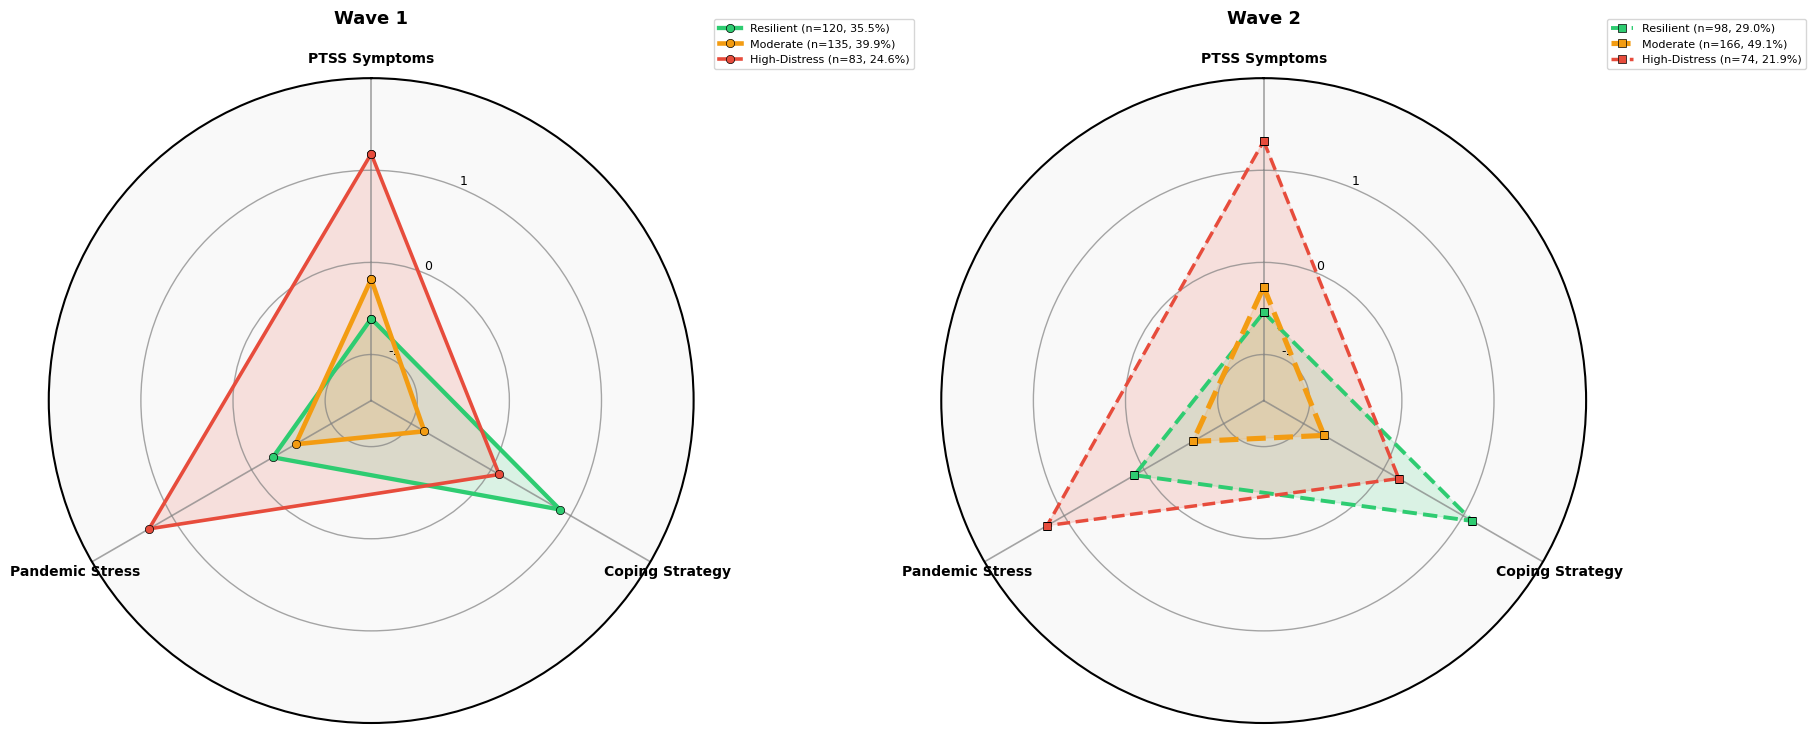

Figure 2: Radar profiles saved


In [128]:
import numpy as np
import matplotlib.pyplot as plt

def plot_radar(ax, centers, profile_names, sizes, title):
    N = len(features)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the loop
    total = sum(sizes.values())

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.grid(True, color='gray', linewidth=1.2, linestyle='-', alpha=0.7)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=10, fontweight='bold')
    

    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['-1', '0', '1'], fontsize=9)
    ax.yaxis.grid(True, color='gray', linewidth=1.0, linestyle='-', alpha=0.7)
    
    ax.spines['polar'].set_linewidth(1.5)
    ax.spines['polar'].set_color('black')

    ax.set_facecolor('#f9f9f9')
    
    for profile in PROFILE_ORDER:
        cidx = [i for i, n in profile_names.items() if n == profile][0]
        n = sizes[cidx]
        weight = n / total if total > 0 else 0
        vals = centers[cidx].tolist() + [centers[cidx][0]]
        color = PROFILE_COLORS[profile]
        lw = 1.5 + weight * 4.5
        style = 'o-' if 'Wave 1' in title else 's--'
        ax.plot(angles, vals, style, lw=lw, color=color, markersize=6,
                markeredgecolor='black', markeredgewidth=0.5,
                label=f'{SHORT_NAMES[profile]} (n={n}, {weight*100:.1f}%)')
        ax.fill(angles, vals, alpha=0.15, color=color)

    ax.set_ylim(-1.5, 2.0)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.10), fontsize=8, frameon=True)


fig, axs = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': 'polar'})
plot_radar(axs[0], centers_pre_std, profile_names_pre, pre_sizes, 'Wave 1')
plot_radar(axs[1], centers_post_aligned, profile_names_post, post_sizes_aligned, 'Wave 2')
plt.tight_layout()
plt.savefig('fig2_radar_profiles.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 2: Radar profiles saved")

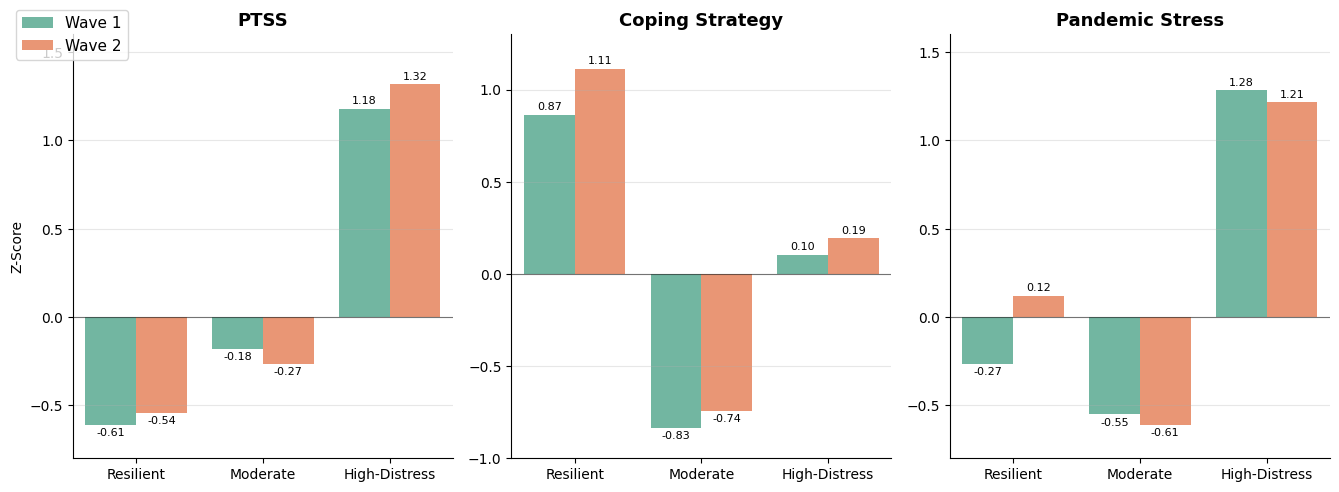

Figure 3: Bar plot saved


In [129]:
plot_rows = []
for i in range(3):
    plot_rows.append({'Period': 'Wave 1', 'Clinical Profile': profile_names_pre[i],
                      'PTSS': centers_pre_std[i][0],
                      'Coping Strategy': centers_pre_std[i][1],
                      'Pandemic Stress': centers_pre_std[i][2]})
    plot_rows.append({'Period': 'Wave 2', 'Clinical Profile': profile_names_post[i],
                      'PTSS': centers_post_aligned[i][0],
                      'Coping Strategy': centers_post_aligned[i][1],
                      'Pandemic Stress': centers_post_aligned[i][2]})

plot_df = pd.DataFrame(plot_rows)
df_melt = plot_df.melt(id_vars=['Period', 'Clinical Profile'],
                       value_vars=['PTSS', 'Coping Strategy', 'Pandemic Stress'],
                       var_name='Variable', value_name='Z-Score')

g = sns.FacetGrid(df_melt, col='Variable', height=5, aspect=0.9, sharey=False)
g.map_dataframe(sns.barplot, x='Clinical Profile', y='Z-Score', hue='Period',
                order=PROFILE_ORDER, palette='Set2', errorbar=None)

short_labels = [SHORT_NAMES[p] for p in PROFILE_ORDER]
ylims = {'PTSS': (-0.8, 1.6), 'Coping Strategy': (-1.0, 1.3), 'Pandemic Stress': (-0.8, 1.6)}
for ax, var in zip(g.axes.flat, ['PTSS', 'Coping Strategy', 'Pandemic Stress']):
    ax.set_title(var, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(short_labels, fontsize=10)
    ax.set_ylim(ylims[var])
    ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
    ax.grid(True, alpha=0.3, axis='y')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

handles, lbls = g.axes[0, 0].get_legend_handles_labels()
g.fig.legend(handles=handles, labels=['Wave 1', 'Wave 2'],
             loc='upper left', bbox_to_anchor=(0.01, 0.99), fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig('fig3_barplot_profiles.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 3: Bar plot saved")

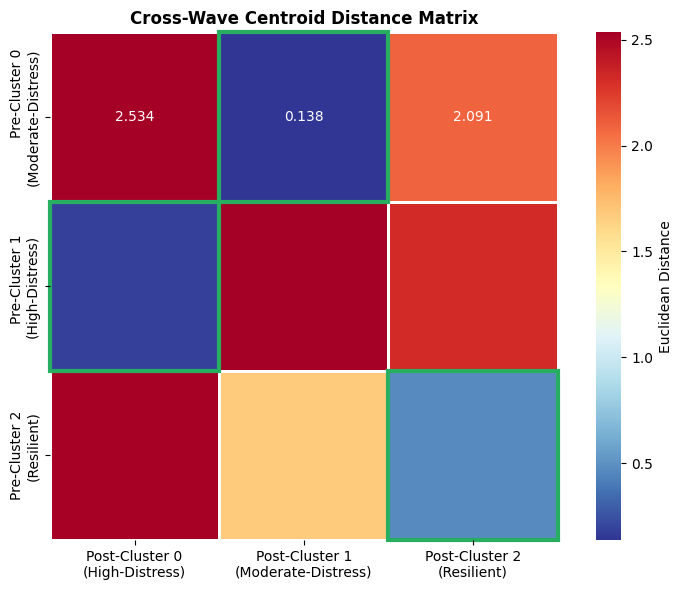

Figure 4: Centroid distance heatmap saved


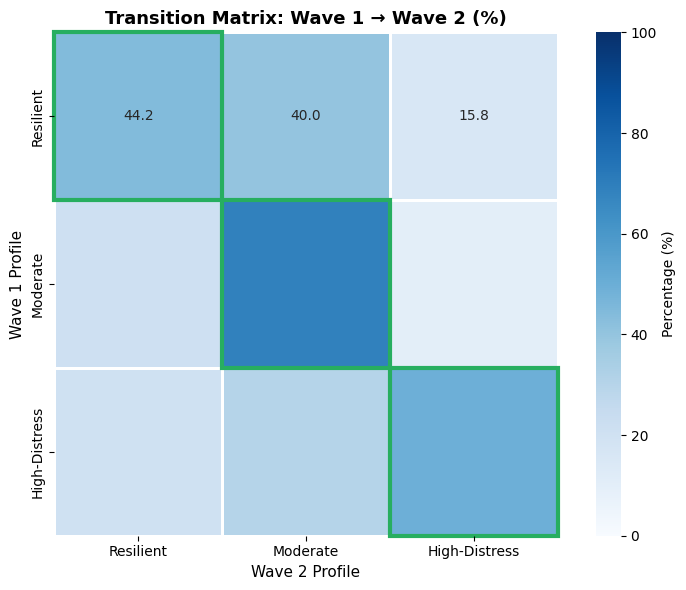

Figure 5: Transition heatmap saved


In [130]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(dist_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r',
            xticklabels=[f'Post-Cluster {i}\n({profile_names_post[post_label_mapping[i]]})' for i in range(3)],
            yticklabels=[f'Pre-Cluster {i}\n({profile_names_pre[i]})' for i in range(3)],
            square=True, linewidths=2, ax=ax,
            cbar_kws={'label': 'Euclidean Distance'})
ax.set_title('Cross-Wave Centroid Distance Matrix', fontsize=12, fontweight='bold')
for r, c in zip(row_ind, col_ind):
    ax.add_patch(patches.Rectangle((c, r), 1, 1, fill=False, edgecolor='#27AE60', lw=3, clip_on=False))
plt.tight_layout()
plt.savefig('fig4_centroid_distance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4: Centroid distance heatmap saved")

# Figure 5: Transition heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(transition_pct, annot=True, fmt='.1f', cmap='Blues',
            square=True, linewidths=2, ax=ax, vmin=0, vmax=100,
            cbar_kws={'label': 'Percentage (%)'},
            xticklabels=[SHORT_NAMES[p] for p in PROFILE_ORDER],
            yticklabels=[SHORT_NAMES[p] for p in PROFILE_ORDER])
ax.set_title('Transition Matrix: Wave 1 → Wave 2 (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Wave 2 Profile', fontsize=11)
ax.set_ylabel('Wave 1 Profile', fontsize=11)
for i in range(3):
    ax.add_patch(patches.Rectangle((i, i), 1, 1, fill=False, edgecolor='#27AE60', lw=3, clip_on=False))
plt.tight_layout()
plt.savefig('fig5_transition_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 5: Transition heatmap saved")

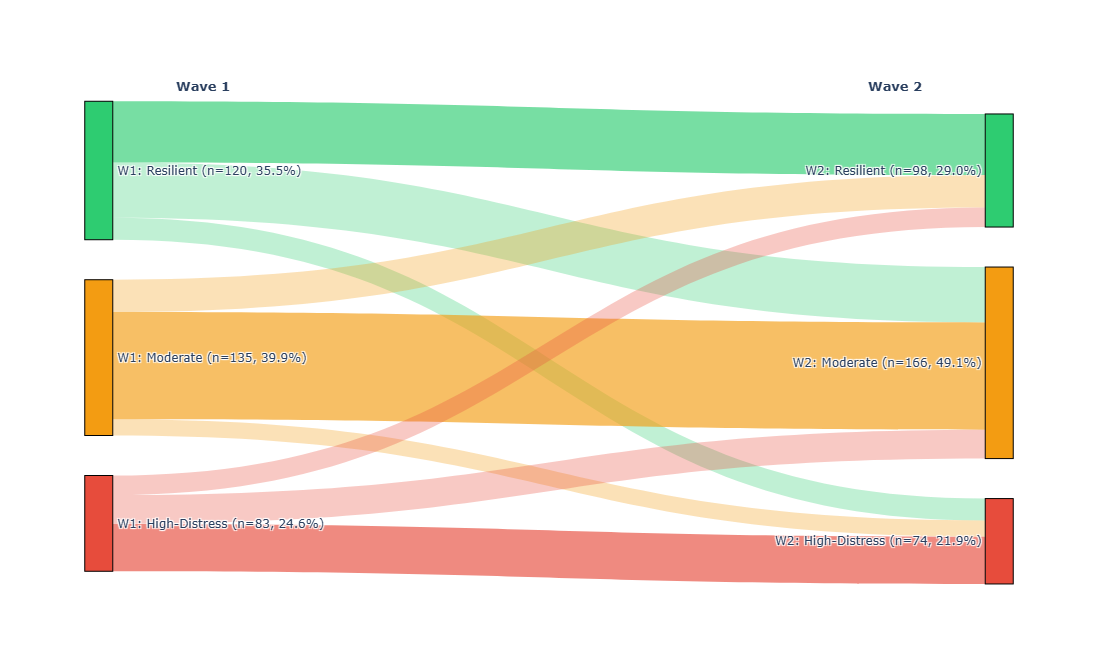

Figure 6: Sankey diagram saved (fig6_sankey.html)


In [131]:
wave1_n = transition_counts.sum(axis=1)
wave2_n = transition_counts.sum(axis=0)
total = transition_counts.values.sum()

node_labels = (
    [f"W1: {SHORT_NAMES[p]}\n(n={wave1_n[p]}, {wave1_n[p]/total*100:.1f}%)" for p in PROFILE_ORDER] +
    [f"W2: {SHORT_NAMES[p]}\n(n={wave2_n[p]}, {wave2_n[p]/total*100:.1f}%)" for p in PROFILE_ORDER]
)
node_colors = [PROFILE_COLORS[p] for p in PROFILE_ORDER] * 2

sources, targets, values, link_colors, link_labels = [], [], [], [], []
for i, fp in enumerate(PROFILE_ORDER):
    for j, tp in enumerate(PROFILE_ORDER):
        cnt = int(transition_counts.loc[fp, tp])
        if cnt > 0:
            pct_val = transition_pct.loc[fp, tp]
            sources.append(i)
            targets.append(j + 3)
            values.append(cnt)
            link_labels.append(f"{SHORT_NAMES[fp]} to {SHORT_NAMES[tp]}: {cnt} ({pct_val:.1f}%)")
            hx = PROFILE_COLORS[fp].lstrip('#')
            r_c, g_c, b_c = int(hx[0:2],16), int(hx[2:4],16), int(hx[4:6],16)
            alpha = 0.65 if fp == tp else 0.30
            link_colors.append(f'rgba({r_c},{g_c},{b_c},{alpha})')

sankey_fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(pad=40, thickness=28, label=node_labels, color=node_colors,
              line=dict(color='black', width=1),
              x=[0.02]*3 + [0.98]*3, y=[0.15, 0.50, 0.85, 0.15, 0.50, 0.85]),
    link=dict(source=sources, target=targets, value=values, color=link_colors,
              label=link_labels, hovertemplate='%{label}<extra></extra>'),
))

sankey_fig.update_layout(
    title=dict(text='', font=dict(size=18), x=0.5, xanchor='center'),
    width=1200, height=650, paper_bgcolor='white',
    annotations=[
        dict(x=0.10, y=1.05, xref='paper', yref='paper', text='<b>Wave 1</b>', showarrow=False, font=dict(size=13)),
        dict(x=0.90, y=1.05, xref='paper', yref='paper', text='<b>Wave 2</b>', showarrow=False, font=dict(size=13)),
    ]
)

html_str = sankey_fig.to_html(full_html=True)
with open('fig6_sankey.html', 'w', encoding='utf-8') as f:
    f.write(html_str)
sankey_fig.show()
print("Figure 6: Sankey diagram saved (fig6_sankey.html)")

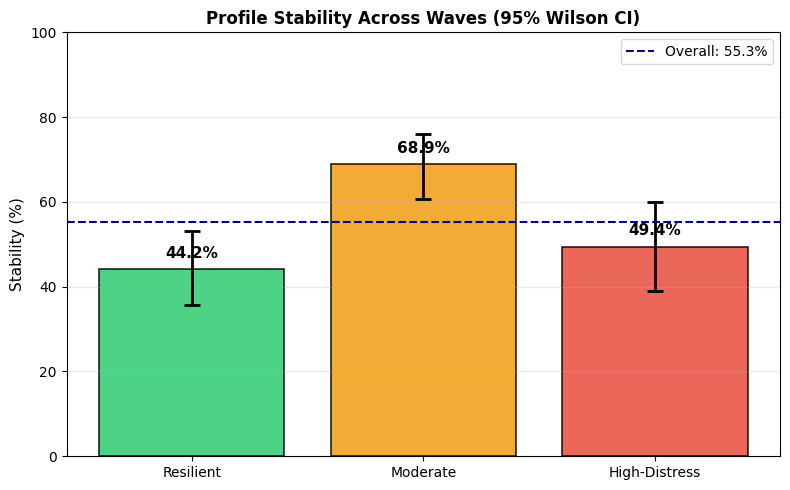

Figure 7: Stability bar chart saved


In [132]:
# Figure 7: Stability bar chart
stab_pcts, stab_lo, stab_hi = [], [], []
for p in PROFILE_ORDER:
    n1 = int(transition_counts.loc[p].sum())
    ns = int(transition_counts.loc[p, p])
    pct = ns / n1 * 100 if n1 else 0
    lo, hi = wilson_ci(ns, n1)
    stab_pcts.append(pct)
    stab_lo.append(pct - lo)
    stab_hi.append(hi - pct)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([SHORT_NAMES[p] for p in PROFILE_ORDER], stab_pcts,
              color=[PROFILE_COLORS[p] for p in PROFILE_ORDER], edgecolor='black', linewidth=1.2, alpha=0.85)
ax.errorbar([SHORT_NAMES[p] for p in PROFILE_ORDER], stab_pcts,
            yerr=[stab_lo, stab_hi], fmt='none', color='black', capsize=6, capthick=2, linewidth=2)

for bar, pct in zip(bars, stab_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=op, color='navy', linestyle='--', linewidth=1.5, label=f'Overall: {op:.1f}%')
ax.set_ylim(0, 100)
ax.set_ylabel('Stability (%)', fontsize=11)
ax.set_title('Profile Stability Across Waves (95% Wilson CI)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig7_stability_bars.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 7: Stability bar chart saved")

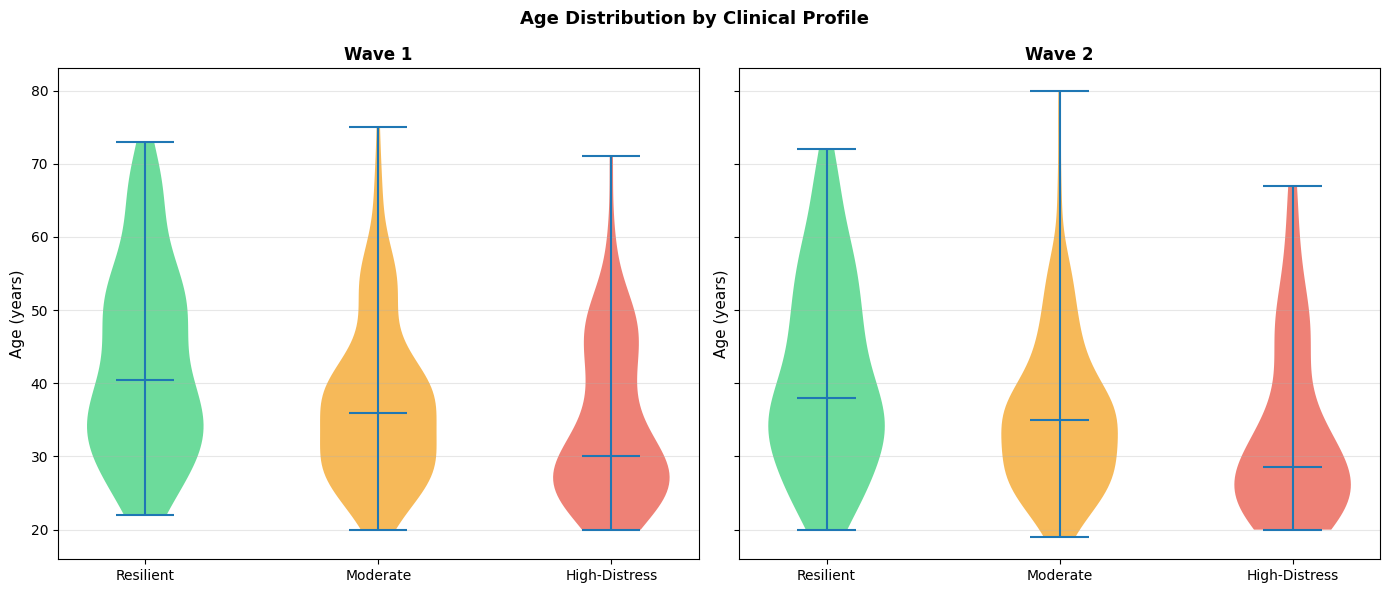

Figure 8: Age violin plot saved


In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, df_w, title in [(axes[0], data_pre_prof, 'Wave 1'), (axes[1], data_post_prof, 'Wave 2')]:
    if 'Age' in df_w.columns:
        plot_data = [df_w[df_w['Profile'] == p]['Age'].dropna().values for p in PROFILE_ORDER]
        parts = ax.violinplot(plot_data, positions=range(len(PROFILE_ORDER)), showmedians=True, showextrema=True)
        for i, (pc, prof) in enumerate(zip(parts['bodies'], PROFILE_ORDER)):
            pc.set_facecolor(PROFILE_COLORS[prof])
            pc.set_alpha(0.7)
        ax.set_xticks(range(len(PROFILE_ORDER)))
        ax.set_xticklabels([SHORT_NAMES[p] for p in PROFILE_ORDER], fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel('Age (years)', fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Age Distribution by Clinical Profile', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_age_violin.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 8: Age violin plot saved")

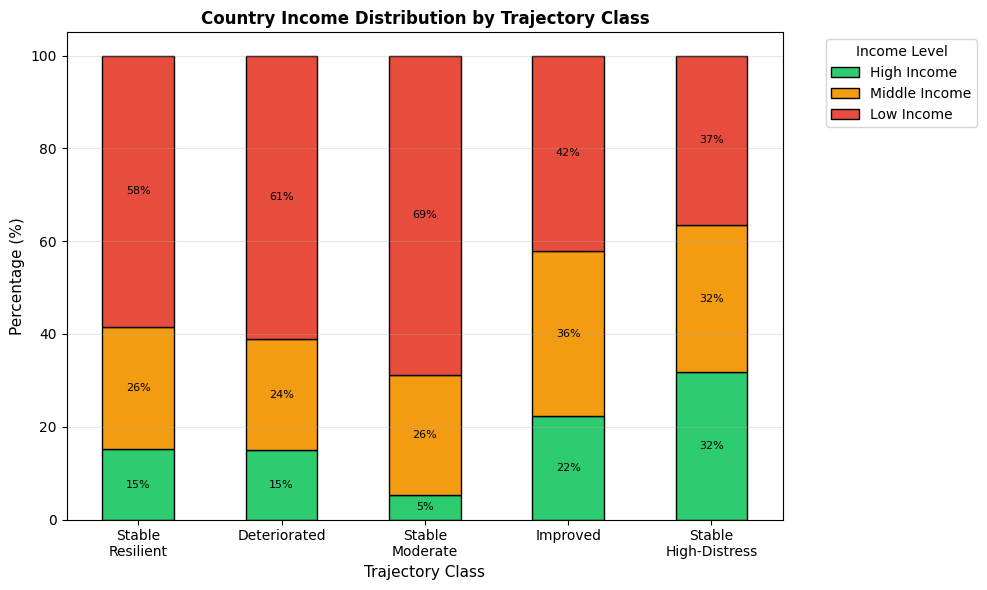

Figure 9: Income by trajectory saved


In [134]:
fig, ax = plt.subplots(figsize=(10, 6))
ct_income_traj = pd.crosstab(df_long['Trajectory'], df_long['Income_Group'], normalize='index') * 100
ct_income_traj = ct_income_traj.reindex(index=TRAJECTORY_ORDER, columns=income_order_3cat, fill_value=0)

ct_income_traj.plot(kind='bar', stacked=True, ax=ax, color=['#2ECC71', '#F39C12', '#E74C3C'], edgecolor='black')
ax.set_xlabel('Trajectory Class', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Country Income Distribution by Trajectory Class', fontsize=12, fontweight='bold')
ax.legend(title='Income Level', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels([t.replace(' ', '\n') for t in TRAJECTORY_ORDER], rotation=0, ha='center')
ax.grid(True, alpha=0.3, axis='y')

for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', fontsize=8, label_type='center')

plt.tight_layout()
plt.savefig('fig9_income_by_trajectory.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 9: Income by trajectory saved")

In [135]:
print(" SUMMARY")

nt = len(data_pre_prof)

print("\n1. CLUSTER VALIDATION (k=3):")
print(f"   Wave 1 — Silhouette={sil_pre:.3f}, Davies-Bouldin={db_pre:.3f}, Calinski-Harabasz={ch_pre:.1f}")
print(f"   Wave 2 — Silhouette={sil_post:.3f}, Davies-Bouldin={db_post:.3f}, Calinski-Harabasz={ch_post:.1f}")

print("\n2. HUNGARIAN MATCHING:")
for r, c in zip(row_ind, col_ind):
    print(f"   Pre-Cluster {r} ({profile_names_pre[r]}) → Post-Cluster {c} (distance={dist_matrix[r,c]:.3f})")
print(f"   Ratio (non-matched/matched): {ratio:.1f}x")

print("\n3. CLINICAL PROFILES (Wave 1):")
for i, p in profile_names_pre.items():
    c = centers_pre_std[i]
    n = pre_sizes[i]
    print(f"   {p} (n={n}, {n/nt*100:.1f}%): PTSS={c[0]:+.2f}, Coping={c[1]:+.2f}, Stress={c[2]:+.2f}")

print("\n4. CLINICAL PROFILES (Wave 2, aligned):")
for i, p in profile_names_post.items():
    c = centers_post_aligned[i]
    n = post_sizes_aligned[i]
    print(f"   {p} (n={n}, {n/nt*100:.1f}%): PTSS={c[0]:+.2f}, Coping={c[1]:+.2f}, Stress={c[2]:+.2f}")

print("\n5. TRANSITION MATRIX (%):")
print(transition_pct.round(1).to_string())

print(f"\n6. STABILITY: {op:.1f}% overall (95% CI [{lo_all:.1f}%, {hi_all:.1f}%])")

print("\n7. INCOME AS PREDICTOR (Logistic Regression):")
if OR_resilient is not None:
    print(f"   High vs Low Income predicting deterioration from Resilient: OR={OR_resilient:.2f}, 95% CI [{CI_resilient[0]:.2f}, {CI_resilient[1]:.2f}], p={p_resilient:.4f}")
else:
    print("   High vs Low Income predicting deterioration from Resilient: Not calculated")

if OR_hd is not None:
    print(f"   High vs Low Income predicting improvement from High-Distress: OR={OR_hd:.2f}, 95% CI [{CI_hd[0]:.2f}, {CI_hd[1]:.2f}], p={p_hd_logistic:.4f}")
else:
    print("   High vs Low Income predicting improvement from High-Distress: Not calculated")

if OR_moderate is not None:
    print(f"   Low vs High Income predicting stability in Moderate: OR={OR_moderate:.2f}, 95% CI [{CI_moderate[0]:.2f}, {CI_moderate[1]:.2f}], p={p_moderate:.4f}")
else:
    print("   Low vs High Income predicting stability in Moderate: Not calculated")

print("\n8. CROSS-SECTIONAL INCOME ASSOCIATIONS:")
if chi2_pre_inc is not None:
    print(f"   Wave 1: χ²={chi2_pre_inc:.2f}, p={p_pre_inc:.4f}, V={v_pre_inc:.3f}")
    print(f"   Wave 2: χ²={chi2_post_inc:.2f}, p={p_post_inc:.4f}, V={v_post_inc:.3f}")
else:
    print("   Income associations could not be calculated due to insufficient data.")

print("\n9. TRAJECTORY CLASS SIZES:")
for t in TRAJECTORY_ORDER:
    n = (df_long['Trajectory'] == t).sum()
    print(f"   {t}: n={n} ({n/len(df_long)*100:.1f}%)")
n_other = (df_long['Trajectory'] == 'Other').sum()
print(f"   Other (mixed transitions): n={n_other} ({n_other/len(df_long)*100:.1f}%)")

 SUMMARY

1. CLUSTER VALIDATION (k=3):
   Wave 1 — Silhouette=0.314, Davies-Bouldin=1.065, Calinski-Harabasz=187.5
   Wave 2 — Silhouette=0.357, Davies-Bouldin=1.015, Calinski-Harabasz=205.1

2. HUNGARIAN MATCHING:
   Pre-Cluster 0 (Moderate-Distress) → Post-Cluster 1 (distance=0.138)
   Pre-Cluster 1 (High-Distress) → Post-Cluster 0 (distance=0.179)
   Pre-Cluster 2 (Resilient) → Post-Cluster 2 (distance=0.466)
   Ratio (non-matched/matched): 8.7x

3. CLINICAL PROFILES (Wave 1):
   Moderate-Distress (n=135, 39.9%): PTSS=-0.18, Coping=-0.83, Stress=-0.55
   High-Distress (n=83, 24.6%): PTSS=+1.18, Coping=+0.10, Stress=+1.28
   Resilient (n=120, 35.5%): PTSS=-0.61, Coping=+0.87, Stress=-0.27

4. CLINICAL PROFILES (Wave 2, aligned):
   Moderate-Distress (n=166, 49.1%): PTSS=-0.27, Coping=-0.74, Stress=-0.61
   High-Distress (n=74, 21.9%): PTSS=+1.32, Coping=+0.19, Stress=+1.21
   Resilient (n=98, 29.0%): PTSS=-0.54, Coping=+1.11, Stress=+0.12

5. TRANSITION MATRIX (%):
Profile_Wave2     

In [138]:
df_long_reg = data_pre[['PTSS Symptoms', 'Coping Strategy']].copy()
df_long_reg['W2_PTSS'] = data_post['PTSS Symptoms'].values
df_long_reg['Age'] = data_pre['Age']
df_long_reg['Gender'] = data_pre['Gender']           
df_long_reg['Education'] = data_pre['Level of Education']   
df_long_reg['Income'] = data_pre['Country Income Profile']  


df_long_reg['Gender_Female'] = (df_long_reg['Gender'] == 2).astype(int)

df_long_reg['HigherEd'] = (df_long_reg['Education'] == 4).astype(int)

df_long_reg['HighIncome'] = (df_long_reg['Income'] == 4).astype(int)

X = df_long_reg[['Coping Strategy', 'PTSS Symptoms', 'Age', 'Gender_Female', 'HigherEd', 'HighIncome']]
X = sm.add_constant(X)  
y = df_long_reg['W2_PTSS']

model = sm.OLS(y, X).fit(cov_type='HC3') 


print("="*70)
print("Longitudinal Regression: Wave 1 Coping → Wave 2 PTSS")
print("="*70)
print(model.summary())

coef = model.params
conf = model.conf_int()
pvals = model.pvalues

results_df = pd.DataFrame({
    'Predictor': coef.index,
    'β': coef.values,
    '95% CI Lower': conf[0],
    '95% CI Upper': conf[1],
    'p-value': pvals.values
})

results_df['β'] = results_df['β'].round(3)
results_df['95% CI Lower'] = results_df['95% CI Lower'].round(3)
results_df['95% CI Upper'] = results_df['95% CI Upper'].round(3)
results_df['p-value'] = results_df['p-value'].round(4)

print("\nCoefficient table (rounded):")
print(results_df.to_string(index=False))

results_df.to_csv('supplementary_table_regression.csv', index=False)

if results_df.loc[results_df['Predictor'] == 'Coping Strategy', 'p-value'].values[0] >= 0.05:
    print("\nInterpretation: Wave 1 coping did NOT significantly predict Wave 2 PTSS after controlling for Wave 1 PTSS and demographics.")
else:
    print("\nInterpretation: Wave 1 coping significantly predicted Wave 2 PTSS after controlling for covariates.")

Longitudinal Regression: Wave 1 Coping → Wave 2 PTSS
                            OLS Regression Results                            
Dep. Variable:                W2_PTSS   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     39.73
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           2.57e-36
Time:                        21:15:57   Log-Likelihood:                -1237.9
No. Observations:                 338   AIC:                             2490.
Df Residuals:                     331   BIC:                             2517.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [139]:
# For Wave 1 
ptss_pre_min = data_pre_scaled[:, 0].min()
ptss_pre_max = data_pre_scaled[:, 0].max()
coping_pre_min = data_pre_scaled[:, 1].min()
coping_pre_max = data_pre_scaled[:, 1].max()
stress_pre_min = data_pre_scaled[:, 2].min()
stress_pre_max = data_pre_scaled[:, 2].max()

# For Wave 2 
ptss_post_min = data_post_scaled[:, 0].min()
ptss_post_max = data_post_scaled[:, 0].max()
coping_post_min = data_post_scaled[:, 1].min()
coping_post_max = data_post_scaled[:, 1].max()
stress_post_min = data_post_scaled[:, 2].min()
stress_post_max = data_post_scaled[:, 2].max()

print("\nStandardized Minimum and Maximum Values:")
print("-" * 70)
print(f"{'Variable':<25} {'Wave 1 (Min → Max)':<25} {'Wave 2 (Min → Max)':<25}")
print("-" * 70)
print(f"{'PTSS Symptoms':<25} {ptss_pre_min:>6.2f} → {ptss_pre_max:<6.2f}       {ptss_post_min:>6.2f} → {ptss_post_max:<6.2f}")
print(f"{'Coping Strategy':<25} {coping_pre_min:>6.2f} → {coping_pre_max:<6.2f}       {coping_post_min:>6.2f} → {coping_post_max:<6.2f}")
print(f"{'Pandemic Stress':<25} {stress_pre_min:>6.2f} → {stress_pre_max:<6.2f}       {stress_post_min:>6.2f} → {stress_post_max:<6.2f}")


Standardized Minimum and Maximum Values:
----------------------------------------------------------------------
Variable                  Wave 1 (Min → Max)        Wave 2 (Min → Max)       
----------------------------------------------------------------------
PTSS Symptoms              -1.10 → 3.05          -1.21 → 3.63  
Coping Strategy            -1.75 → 2.76          -1.11 → 2.84  
Pandemic Stress            -1.23 → 3.40          -0.99 → 3.61  
